# Lesson 3: Regression - Predicting Numbers with Gradient Descent

In Lesson 2, we trained an image classifier using fastai. We watched loss drop, accuracy rise, and a model go from random guesses to 90%+ accuracy. But fastai did everything behind the scenes - the loss function, the training loop, the gradient updates. We saw the dashboard, not the engine.

This lesson opens the hood. We build a model from scratch - pure Python and NumPy first, then PyTorch - and understand every single step of how it learns.

In [101]:
# Setup - run this first
# If you're using the Colab extension in VS Code, upload the repo's data/ folder to the runtime:
#   Right-click the 'data' folder in VS Code -> "Upload to Colab Session"
from pathlib import Path
try:
    import google.colab
    DATA_PATH = Path('/content/data')
except ImportError:
    DATA_PATH = Path('../../../../data')
print(f"Data path: {DATA_PATH}")

Data path: ../../../../data


In [102]:
# === VISUALIZATION HELPERS (hidden to reduce clutter) ===
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

def plot_gradient_descent_1d(f, df, x_start, lr, n_steps, x_range, title="Gradient Descent"):
    x = np.linspace(x_range[0], x_range[1], 200)
    y = f(x)
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.plot(x, y, 'b-', linewidth=2.5, label='Loss function')
    x_current = x_start
    positions = [x_current]
    for step in range(n_steps):
        y_current = f(x_current)
        gradient = df(x_current)
        color = plt.cm.Reds(0.3 + 0.7 * step / n_steps)
        ax.scatter([x_current], [y_current], color=color, s=100, zorder=5)
        tangent_x = np.linspace(x_current - 1.5, x_current + 1.5, 50)
        tangent_y = y_current + gradient * (tangent_x - x_current)
        ax.plot(tangent_x, tangent_y, '--', color=color, alpha=0.5, linewidth=1)
        x_new = x_current - lr * gradient
        positions.append(x_new)
        if abs(x_new - x_current) > 0.05:
            ax.annotate('', xy=(x_new, f(x_new)), xytext=(x_current, y_current),
                       arrowprops=dict(arrowstyle='->', color=color, lw=2))
        x_current = x_new
    ax.scatter([x_current], [f(x_current)], color='green', s=200, zorder=6,
               marker='*', label=f'Final: x={x_current:.2f}')
    ax.set_xlabel('Parameter value', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig, ax, positions

def plot_learning_rate_comparison(f, df, x_start, learning_rates, n_steps, x_range):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    x = np.linspace(x_range[0], x_range[1], 200)
    titles = ['Too Small', 'Just Right', 'Too Large']
    colors = ['blue', 'green', 'red']
    for ax, lr, title, color in zip(axes, learning_rates, titles, colors):
        ax.plot(x, f(x), 'b-', linewidth=2, alpha=0.5)
        x_current = x_start
        path_x, path_y = [x_current], [f(x_current)]
        for _ in range(n_steps):
            x_current = np.clip(x_current - lr * df(x_current), x_range[0], x_range[1])
            path_x.append(x_current)
            path_y.append(f(x_current))
        ax.plot(path_x, path_y, 'o-', color=color, markersize=8, linewidth=2)
        ax.scatter([path_x[0]], [path_y[0]], color='black', s=150, zorder=5, label='Start')
        ax.scatter([path_x[-1]], [path_y[-1]], color=color, s=150, zorder=5, marker='*', label='End')
        ax.set_title(f'{title}\nLR = {lr}', fontsize=12, fontweight='bold', color=color)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig, axes

def plot_loss_landscape(X_norm, y, predict_fn, loss_fn, w_range=(-1, 2), b_range=(0, 4)):
    weight_range = np.linspace(w_range[0], w_range[1], 50)
    bias_range = np.linspace(b_range[0], b_range[1], 50)
    W, B = np.meshgrid(weight_range, bias_range)
    loss_surface = np.zeros_like(W)
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            loss_surface[i, j] = loss_fn(predict_fn(X_norm, W[i, j], B[i, j]), y)
    fig, ax = plt.subplots(figsize=(10, 8))
    contour = ax.contour(W, B, loss_surface, levels=30, cmap='viridis')
    ax.clabel(contour, inline=True, fontsize=8, fmt='%.1f')
    ax.set_xlabel('Weight (w)', fontsize=12)
    ax.set_ylabel('Bias (b)', fontsize=12)
    ax.set_title('Loss Landscape: Finding the Valley', fontsize=14)
    ax.scatter([0.80], [2.07], color='red', s=200, marker='*', zorder=5, label='Optimal point')
    ax.legend()
    plt.colorbar(contour, label='MSE Loss')
    plt.tight_layout()
    plt.show()

def plot_derivative_visual():
    def f(x): return x ** 2
    def df(x): return 2 * x
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    x = np.linspace(-3, 3, 100)
    points = [-2, 0, 1.5]
    titles = ['Steep downhill\n(negative slope)', 'Flat\n(zero slope)', 'Uphill\n(positive slope)']
    colors = ['red', 'green', 'blue']
    for ax, point, title, color in zip(axes, points, titles, colors):
        ax.plot(x, f(x), 'b-', linewidth=2, alpha=0.5)
        ax.scatter([point], [f(point)], color=color, s=150, zorder=5)
        slope = df(point)
        tangent_x = np.linspace(point - 1.5, point + 1.5, 50)
        tangent_y = f(point) + slope * (tangent_x - point)
        ax.plot(tangent_x, tangent_y, '--', color=color, linewidth=2.5, label=f'Slope = {slope:+.1f}')
        ax.set_xlim(-3.5, 3.5); ax.set_ylim(-1, 10)
        ax.set_title(title, fontsize=12, fontweight='bold', color=color)
        ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_training_progress(loss_history, weight_history, bias_history):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, data, label, color, title in zip(
        axes, [loss_history, weight_history, bias_history],
        ['Loss (MSE)', 'Weight', 'Bias'], ['b', 'g', 'm'],
        ['Loss Decreases Over Training', 'Weight Converges', 'Bias Converges']):
        ax.plot(data, f'{color}-', linewidth=2)
        ax.set_xlabel('Iteration', fontsize=11); ax.set_ylabel(label, fontsize=11)
        ax.set_title(title, fontsize=12); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_model_fit(X_train, y_train, X_mean, X_std, weight, bias, predict_fn, sample_n=1000):
    fig, ax = plt.subplots(figsize=(10, 6))
    idx = np.random.choice(len(X_train), min(sample_n, len(X_train)), replace=False)
    ax.scatter(X_train[idx], y_train[idx], alpha=0.3, s=20, label='Training data')
    x_line = np.linspace(X_train.min(), X_train.max(), 100)
    y_line = predict_fn((x_line - X_mean) / X_std, weight, bias)
    ax.plot(x_line, y_line, 'r-', linewidth=2.5, label='Learned linear model')
    ax.set_xlabel('Median Income ($10,000s)', fontsize=12)
    ax.set_ylabel('House Value ($100,000s)', fontsize=12)
    ax.set_title('Gradient Descent Found the Best Fit Line!', fontsize=14)
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_early_stopping_comparison(train_losses, test_losses):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(train_losses, 'b-', linewidth=2, label='Training Loss')
    axes[0].plot(test_losses, 'orange', linewidth=2, linestyle='--', label='Test Loss')
    axes[0].set_xlabel('Iteration', fontsize=12); axes[0].set_ylabel('Loss (MSE)', fontsize=12)
    axes[0].set_title('Our Model: No Overfitting', fontsize=12, color='green')
    axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)
    iters = np.arange(1, 101)
    s_train = 2.5 * np.exp(-0.06 * iters) + 0.3
    s_test = s_train + 0.015 * (iters - 30) * (iters > 30)
    axes[1].plot(iters, s_train, 'b-', linewidth=2, label='Training Loss')
    axes[1].plot(iters, s_test, 'orange', linewidth=2, linestyle='--', label='Test Loss')
    axes[1].axvline(x=30, color='red', linestyle=':', linewidth=2, alpha=0.7)
    axes[1].annotate('Stop here!', xy=(30, s_test[29]), xytext=(50, 2.0),
                    fontsize=12, fontweight='bold', color='red',
                    arrowprops=dict(arrowstyle='->', color='red', lw=2))
    axes[1].fill_between(iters[29:], s_train[29:], s_test[29:], alpha=0.2, color='red', label='Overfitting gap')
    axes[1].set_xlabel('Iteration', fontsize=12); axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].set_title('What Overfitting Looks Like', fontsize=12, color='red')
    axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_polynomial_fits(x_data, y_data, x_plot_range=(0, 8), degrees=[1, 3, 12],
                         titles=None, colors=None, ylim=(-2, 7)):
    if titles is None: titles = [f'Degree {d}' for d in degrees]
    if colors is None: colors = ['red', 'green', 'purple']
    x_plot = np.linspace(x_plot_range[0], x_plot_range[1], 300)
    fig, axes = plt.subplots(1, len(degrees), figsize=(16, 5))
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.linear_model import LinearRegression
    for ax, degree, title, color in zip(axes, degrees, titles, colors):
        ax.scatter(x_data, y_data, color='black', s=60, zorder=5, label='Training data')
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_poly = poly.fit_transform(x_data.reshape(-1, 1))
        model = LinearRegression().fit(X_poly, y_data)
        y_plot = np.clip(model.predict(poly.transform(x_plot.reshape(-1, 1))), ylim[0]-1, ylim[1]+1)
        ax.plot(x_plot, y_plot, color=color, linewidth=2.5)
        ax.set_ylim(ylim); ax.set_xlabel('x'); ax.set_ylabel('y')
        ax.set_title(title, fontsize=13, fontweight='bold', color=color)
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_complexity_curve(degrees, train_mses, test_mses):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(degrees, train_mses, 'b-o', linewidth=2, markersize=8, label='Train MSE')
    ax.plot(degrees, test_mses, 'r--s', linewidth=2, markersize=8, label='Test MSE')
    best_idx = np.argmin(test_mses)
    best_degree = degrees[best_idx]
    ax.scatter([best_degree], [test_mses[best_idx]], color='green', s=200, zorder=5,
               marker='*', label=f'Best: degree {best_degree}')
    if best_degree < max(degrees):
        ax.axvspan(best_degree + 0.5, max(degrees) + 0.5, alpha=0.1, color='red', label='Overfitting zone')
    ax.set_xlabel('Polynomial Degree (model complexity)', fontsize=12)
    ax.set_ylabel('MSE', fontsize=12)
    ax.set_title('The Overfitting Curve: More Complexity ≠ Better', fontsize=14)
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3); ax.set_xticks(degrees)
    plt.tight_layout()
    plt.show()
    return best_degree

def plot_extrapolation(x_data, y_data, x_range=(-1, 10), degrees=[3, 12],
                       colors=['green', 'purple'], train_range=(0.5, 7.5)):
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.linear_model import LinearRegression
    x_ext = np.linspace(x_range[0], x_range[1], 500)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.scatter(x_data, y_data, color='black', s=80, zorder=5, label='Training data')
    for degree, color in zip(degrees, colors):
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        model = LinearRegression().fit(poly.fit_transform(x_data.reshape(-1, 1)), y_data)
        y_ext = model.predict(poly.transform(x_ext.reshape(-1, 1)))
        ax.plot(x_ext, y_ext, color=color, linewidth=2.5, label=f'Degree {degree}')
    ax.axvspan(x_range[0], train_range[0], alpha=0.15, color='red', label='Extrapolation zone')
    ax.axvspan(train_range[1], x_range[1], alpha=0.15, color='red')
    ax.axvline(x=train_range[0], color='gray', linestyle=':', alpha=0.5)
    ax.axvline(x=train_range[1], color='gray', linestyle=':', alpha=0.5)
    ax.set_ylim(-5, 10); ax.set_xlabel('x', fontsize=12); ax.set_ylabel('y', fontsize=12)
    ax.set_title('Extrapolation: Overfit Models Explode Outside Training Range', fontsize=14)
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_feature_bars(names, weights, title='Feature Importance', noise_prefix=None):
    sorted_idx = np.argsort(np.abs(weights))
    sorted_names = np.array(names)[sorted_idx]
    sorted_weights = weights[sorted_idx]
    colors = []
    for name, w in zip(sorted_names, sorted_weights):
        if noise_prefix and noise_prefix in str(name):
            colors.append('#95a5a6')
        elif w < 0:
            colors.append('#e74c3c')
        else:
            colors.append('#2ecc71')
    fig, ax = plt.subplots(figsize=(10, max(4, len(names) * 0.45)))
    ax.barh(sorted_names, sorted_weights, color=colors)
    ax.set_xlabel('Weight (on standardized features)', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

def plot_r2_progression(labels, scores):
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6'][:len(labels)]
    bars = ax.barh(labels, scores, color=colors)
    for bar, score in zip(bars, scores):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{score:.3f}', va='center', fontsize=12, fontweight='bold')
    ax.set_xlabel('R² (proportion of variance explained)', fontsize=12)
    ax.set_title('More Relevant Features → Better Predictions', fontsize=14)
    ax.set_xlim(0, 0.75); ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()


def plot_regression_intro(income, price, sample_n=1000):
    rng = np.random.RandomState(42)
    idx = rng.choice(len(income), min(sample_n, len(income)), replace=False)
    x_s, y_s = income[idx], price[idx]
    x_line = np.linspace(0, 15, 100)
    lines = [
        (0.0, 2.1, 'Flat line - ignores income', '#e74c3c'),
        (0.15, 1.5, 'Some slope - getting warmer', '#e67e22'),
        (0.42, 0.45, 'Best fit - captures the trend', '#2ecc71'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, (slope, intercept, title, color) in zip(axes, lines):
        ax.scatter(x_s, y_s, alpha=0.2, s=10, color='steelblue')
        ax.plot(x_line, slope * x_line + intercept, color=color, linewidth=3)
        ax.set_xlabel('Median Income ($10,000s)', fontsize=11)
        ax.set_ylabel('House Value ($100,000s)', fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold', color=color)
        ax.set_ylim(0, 5.5)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def draw_batch_gd_diagram(X_data, y_data, weights, bias, feature_names, n_total_rows):
    predictions = X_data @ weights + bias
    errors = predictions - y_data
    n_rows = len(X_data)
    n_feat = len(feature_names)

    fig, ax = plt.subplots(figsize=(15, 7))
    ax.axis('off')
    ax.set_xlim(-1.5, 15.5)
    ax.set_ylim(-2, 8)

    cw, ch = 1.8, 0.7
    CELL_BG = '#f7f7f7'
    CELL_EC = '#555555'
    BRACKET_COLOR = '#333333'

    def draw_bracket(ax, x, y_top, y_bot, side='left'):
        bw = 0.15
        sign = -1 if side == 'left' else 1
        ax.plot([x + sign*bw, x, x, x + sign*bw],
                [y_top, y_top, y_bot, y_bot],
                color=BRACKET_COLOR, lw=1.8, solid_capstyle='round')

    # ── Weight vector (horizontal, top) ──
    wx, wy = 0.5, 6.5
    ax.text(wx + n_feat*cw/2, wy + ch + 0.25, 'weights', ha='center', fontsize=11, fontweight='bold')
    draw_bracket(ax, wx - 0.05, wy + ch, wy, side='left')
    draw_bracket(ax, wx + n_feat*cw + 0.05, wy + ch, wy, side='right')
    for j in range(n_feat):
        rect = plt.Rectangle((wx + j*cw, wy), cw - 0.08, ch,
                             facecolor=CELL_BG, edgecolor=CELL_EC, linewidth=1)
        ax.add_patch(rect)
        ax.text(wx + j*cw + cw/2, wy + ch/2, f'{weights[j]:+.3f}',
                ha='center', va='center', fontsize=10, family='monospace')
    # Feature labels below weight cells
    for j, name in enumerate(feature_names):
        ax.text(wx + j*cw + cw/2, wy - 0.2, name,
                ha='center', va='top', fontsize=7, color='#888888')

    # Bias cell
    bx = wx + n_feat*cw + 0.8
    rect = plt.Rectangle((bx, wy), cw*0.65, ch,
                         facecolor=CELL_BG, edgecolor=CELL_EC, linewidth=1)
    ax.add_patch(rect)
    ax.text(bx + cw*0.325, wy + ch/2, f'{bias:.3f}',
            ha='center', va='center', fontsize=10, family='monospace')
    ax.text(bx + cw*0.325, wy + ch + 0.25, 'bias', ha='center', fontsize=10, fontweight='bold')

    # ── Data matrix (left) ──
    dx, dy_start = 0.5, 3.5
    row_gap = 1.5
    ax.text(dx + n_feat*cw/2, dy_start + ch + 0.25, 'X  (data matrix)', ha='center', fontsize=11, fontweight='bold')
    # Column headers
    for j, name in enumerate(feature_names):
        ax.text(dx + j*cw + cw/2, dy_start + ch + 0.05, name,
                ha='center', va='bottom', fontsize=7, color='#888888')

    for i in range(n_rows):
        row_y = dy_start - i * row_gap
        # Left bracket
        draw_bracket(ax, dx - 0.05, row_y + ch, row_y, side='left')
        draw_bracket(ax, dx + n_feat*cw + 0.05, row_y + ch, row_y, side='right')
        # Row label
        ax.text(dx - 0.35, row_y + ch/2, f'row {i+1}',
                ha='right', va='center', fontsize=8, color='#999999')
        for j in range(n_feat):
            rect = plt.Rectangle((dx + j*cw, row_y), cw - 0.08, ch,
                                 facecolor=CELL_BG, edgecolor=CELL_EC, linewidth=0.8)
            ax.add_patch(rect)
            ax.text(dx + j*cw + cw/2, row_y + ch/2, f'{X_data[i,j]:+.2f}',
                    ha='center', va='center', fontsize=9.5, family='monospace')

        # ── Arrows from each weight cell down to the corresponding data cell ──
        for j in range(n_feat):
            w_center_x = wx + j*cw + cw/2
            d_center_x = dx + j*cw + cw/2
            ax.annotate('',
                xy=(d_center_x, row_y + ch + 0.03),
                xytext=(w_center_x, wy - 0.03),
                arrowprops=dict(arrowstyle='->', color='#bbbbbb', lw=0.7,
                               connectionstyle=f'arc3,rad={0.05 * (j - 1)}'))

        # ── Horizontal arrow to prediction ──
        arrow_x = dx + n_feat*cw + 0.2
        arrow_end = 8.8
        ax.annotate('', xy=(arrow_end, row_y + ch/2), xytext=(arrow_x, row_y + ch/2),
                    arrowprops=dict(arrowstyle='->', color='#555555', lw=1.3))
        mid_x = (arrow_x + arrow_end) / 2
        ax.text(mid_x, row_y + ch/2 + 0.22, 'row \u00b7 w + b',
                ha='center', va='bottom', fontsize=7.5, color='#888888', style='italic')

        # ── Prediction ──
        px = arrow_end + 0.15
        rect = plt.Rectangle((px, row_y), cw*0.75, ch,
                             facecolor=CELL_BG, edgecolor=CELL_EC, linewidth=1)
        ax.add_patch(rect)
        ax.text(px + cw*0.375, row_y + ch/2, f'{predictions[i]:+.3f}',
                ha='center', va='center', fontsize=9.5, family='monospace')

        # ── "- actual = error" ──
        tx = px + cw*0.75 + 0.15
        ax.text(tx, row_y + ch/2, f'\u2212 {y_data[i]:.2f}  =',
                ha='left', va='center', fontsize=9, family='monospace', color='#888888')
        ex = tx + 2.3
        ax.text(ex, row_y + ch/2, f'{errors[i]:+.3f}',
                ha='left', va='center', fontsize=9.5, family='monospace',
                fontweight='bold', color='#c0392b')

    # "..." for remaining rows
    dots_y = dy_start - n_rows * row_gap + 0.3
    ax.text(dx + n_feat*cw/2, dots_y, f'\u22ee  {n_total_rows - n_rows:,} more rows  \u22ee',
            ha='center', fontsize=9, color='#aaaaaa')

    # Column labels
    ax.text(9.6, dy_start + ch + 0.25, '\u0177', fontsize=11, fontweight='bold', ha='center')
    ax.text(13.5, dy_start + ch + 0.25, 'error', fontsize=10, fontweight='bold', color='#c0392b', ha='center')

    # ── Loss ──
    loss_val = (errors**2).mean()
    loss_x, loss_y = 11.5, dots_y - 0.8
    rect = plt.Rectangle((loss_x, loss_y), 3.2, 0.75,
                         facecolor='white', edgecolor='#c0392b', linewidth=2)
    ax.add_patch(rect)
    ax.text(loss_x + 1.6, loss_y + 0.375, f'MSE = {loss_val:.4f}',
            ha='center', va='center', fontsize=11, fontweight='bold', color='#c0392b')
    ax.annotate('', xy=(loss_x + 1.6, loss_y + 0.75),
                xytext=(loss_x + 1.6, dots_y + 0.5),
                arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.3))
    ax.text(loss_x + 1.6, dots_y + 0.55, 'mean(errors\u00b2)',
            ha='center', va='bottom', fontsize=8, color='#c0392b', style='italic')

    plt.tight_layout()
    plt.show()
    return predictions, errors

def plot_error_comparison(x_data, y_data, fits):
    """2-panel comparison showing error lines for different fits.
    fits: list of (slope, intercept, title, color) tuples."""
    fig, axes = plt.subplots(1, len(fits), figsize=(7*len(fits), 5))
    if len(fits) == 1:
        axes = [axes]
    mse_values = []
    for ax, (slope, intercept, title, color) in zip(axes, fits):
        ax.scatter(x_data, y_data, color='steelblue', s=60, zorder=5)
        x_line = np.linspace(x_data.min() - 0.5, x_data.max() + 0.5, 100)
        ax.plot(x_line, slope * x_line + intercept, color=color, linewidth=2.5)
        total_sq_error = 0
        for xi, yi in zip(x_data, y_data):
            pred_i = slope * xi + intercept
            ax.plot([xi, xi], [yi, pred_i], color='red', linewidth=1.5, alpha=0.6)
            total_sq_error += (pred_i - yi) ** 2
        mse = total_sq_error / len(x_data)
        mse_values.append(mse)
        ax.set_xlabel('Median Income ($10,000s)', fontsize=11)
        ax.set_ylabel('House Value ($100,000s)', fontsize=11)
        ax.set_title(f'{title}\nMSE = {mse:.2f}', fontsize=12, fontweight='bold', color=color)
        ax.set_ylim(0, 5.5); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return mse_values

def plot_scaling_landscape(X_raw, X_norm, y, predict_fn, loss_fn):
    """2-panel contour: unscaled (elongated) vs scaled (round) loss landscape with GD paths."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Unscaled
    w_vals = np.linspace(-0.1, 0.7, 50)
    b_vals = np.linspace(-0.5, 2.5, 50)
    W_grid, B_grid = np.meshgrid(w_vals, b_vals)
    loss_raw = np.array([[loss_fn(predict_fn(X_raw, W_grid[i,j], B_grid[i,j]), y)
                          for j in range(50)] for i in range(50)])
    w, b = 0.0, 0.0
    path_w, path_b = [w], [b]
    for _ in range(150):
        errors = predict_fn(X_raw, w, b) - y
        n = len(y)
        w -= 0.001 * (2/n) * (errors * X_raw).sum()
        b -= 0.001 * (2/n) * errors.sum()
        path_w.append(w); path_b.append(b)
    axes[0].contour(W_grid, B_grid, loss_raw, levels=25, cmap='viridis', alpha=0.8)
    axes[0].plot(path_w, path_b, 'r.-', markersize=2, linewidth=1.5, alpha=0.8)
    axes[0].scatter(path_w[0], path_b[0], color='red', s=100, zorder=5, label='Start')
    axes[0].scatter(path_w[-1], path_b[-1], color='#e74c3c', s=150, marker='*', zorder=5, label='After 150 steps')
    axes[0].set_xlabel('Weight', fontsize=11); axes[0].set_ylabel('Bias', fontsize=11)
    axes[0].set_title('Unscaled Features\nElongated valley, indirect path',
                       fontsize=11, fontweight='bold', color='#e74c3c')
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2)

    # Right: Scaled
    w_vals_n = np.linspace(-1, 2, 50)
    b_vals_n = np.linspace(-0.5, 4, 50)
    W_n, B_n = np.meshgrid(w_vals_n, b_vals_n)
    loss_norm = np.array([[loss_fn(predict_fn(X_norm, W_n[i,j], B_n[i,j]), y)
                           for j in range(50)] for i in range(50)])
    w, b = 0.0, 0.0
    path_w, path_b = [w], [b]
    for _ in range(20):
        errors = predict_fn(X_norm, w, b) - y
        n = len(y)
        w -= 0.1 * (2/n) * (errors * X_norm).sum()
        b -= 0.1 * (2/n) * errors.sum()
        path_w.append(w); path_b.append(b)
    axes[1].contour(W_n, B_n, loss_norm, levels=25, cmap='viridis', alpha=0.8)
    axes[1].plot(path_w, path_b, 'r.-', markersize=4, linewidth=1.5, alpha=0.8)
    axes[1].scatter(path_w[0], path_b[0], color='red', s=100, zorder=5, label='Start')
    axes[1].scatter(path_w[-1], path_b[-1], color='#2ecc71', s=150, marker='*', zorder=5, label='After 20 steps')
    axes[1].set_xlabel('Weight', fontsize=11); axes[1].set_ylabel('Bias', fontsize=11)
    axes[1].set_title('Scaled Features\nRound valley, direct path',
                       fontsize=11, fontweight='bold', color='#2ecc71')
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

def plot_scaling_convergence(configs, y, predict_fn, loss_fn, n_iters=100):
    """Convergence curves for different scaling/lr combos.
    configs: list of (label, X_data, lr, color, linestyle) tuples."""
    fig, ax = plt.subplots(figsize=(12, 6))
    for label, X_data, lr, color, style in configs:
        w, b, losses = 0.0, 0.0, []
        for _ in range(n_iters):
            preds = predict_fn(X_data, w, b)
            loss = loss_fn(preds, y)
            losses.append(loss)
            if loss > 1e10:
                break
            errors = preds - y
            n = len(y)
            w -= lr * (2/n) * (errors * X_data).sum()
            b -= lr * (2/n) * errors.sum()
        ax.plot(range(len(losses)), losses, color=color, linewidth=2.5,
                linestyle=style, label=label)
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Loss (MSE)', fontsize=12)
    ax.set_title('Why Feature Scaling Matters', fontsize=14)
    ax.legend(fontsize=11)
    ax.set_ylim(0, 12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_actual_vs_predicted(y_true, predictions_list, labels, r2_scores, colors):
    """Side-by-side actual vs predicted scatter plots."""
    n = len(predictions_list)
    fig, axes = plt.subplots(1, n, figsize=(7*n, 5))
    if n == 1:
        axes = [axes]
    lims = [min(y_true.min(), min(p.min() for p in predictions_list)) - 2,
            max(y_true.max(), max(p.max() for p in predictions_list)) + 2]
    for ax, preds, label, r2, color in zip(axes, predictions_list, labels, r2_scores, colors):
        ax.scatter(y_true, preds, alpha=0.6, s=35, color=color)
        ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect predictions')
        ax.set_xlabel('Actual', fontsize=11)
        ax.set_ylabel('Predicted', fontsize=11)
        ax.set_title(f'{label}: R\u00b2 = {r2:.2f}', fontsize=12, fontweight='bold')
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_line_fitting_intro():
    """Show gradient descent adjusting a line through data over multiple steps."""
    np.random.seed(42)
    n_points = 40
    income = np.random.uniform(2, 12, n_points)
    price = 0.4 * income + 0.8 + np.random.normal(0, 0.5, n_points)
    x_norm = (income - income.mean()) / income.std()
    
    weight, bias = -0.5, 1.0
    lr = 0.1
    snapshots = [(weight, bias, 'Start (random)')]
    for step in range(80):
        preds = weight * x_norm + bias
        errors = preds - price
        weight -= lr * (2 / n_points) * (errors * x_norm).sum()
        bias -= lr * (2 / n_points) * errors.sum()
        if step in [0, 2, 8, 79]:
            label = f'Step {step+1}' if step < 79 else f'Step {step+1} (converged)'
            snapshots.append((weight, bias, label))
    
    fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 4.5), sharey=True)
    colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
    x_line = np.linspace(x_norm.min() - 0.3, x_norm.max() + 0.3, 100)
    
    for ax, (w, b, label), color in zip(axes, snapshots, colors):
        ax.scatter(x_norm, price, alpha=0.5, s=30, color='#555')
        ax.plot(x_line, w * x_line + b, color=color, linewidth=2.5)
        for idx in [0, 10, 20, 30]:
            pred = w * x_norm[idx] + b
            ax.plot([x_norm[idx], x_norm[idx]], [price[idx], pred], color=color, alpha=0.4, linewidth=1)
        mse = ((w * x_norm + b - price) ** 2).mean()
        ax.set_title(f'{label}\nMSE = {mse:.2f}', fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Income (normalized)')
        if ax == axes[0]:
            ax.set_ylabel('House price')
        ax.grid(True, alpha=0.15)
    plt.suptitle('Gradient descent adjusts the line step by step', fontsize=14, fontweight='bold', y=1.04)
    plt.tight_layout()


def plot_gd_ball_rolling(x_start=-2.5, lr=0.15, n_steps=12):
    """Show gradient descent as a ball rolling downhill on a parabola."""
    x_curve = np.linspace(-3, 3, 200)
    y_curve = x_curve ** 2
    
    x_pos = x_start
    positions = [(x_pos, x_pos**2)]
    for _ in range(n_steps):
        gradient = 2 * x_pos
        x_pos = x_pos - lr * gradient
        positions.append((x_pos, x_pos**2))
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(x_curve, y_curve, 'b-', linewidth=2.5, alpha=0.7)
    
    xs, ys = zip(*positions)
    for i in range(len(positions) - 1):
        ax.annotate('', xy=(xs[i+1], ys[i+1]), xytext=(xs[i], ys[i]),
                    arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5, alpha=0.6))
    
    colors_arr = plt.cm.Reds(np.linspace(0.3, 0.9, len(positions)))
    for i, (x, y) in enumerate(positions):
        ax.plot(x, y, 'o', color=colors_arr[i], markersize=10, zorder=5)
        if i == 0:
            ax.annotate('Start\n(random)', (x, y), textcoords='offset points',
                       xytext=(-40, 15), fontsize=10, fontweight='bold', color='#e74c3c')
        elif i == len(positions) - 1:
            ax.annotate(f'After {i} steps\n(near minimum)', (x, y), textcoords='offset points',
                       xytext=(15, 15), fontsize=10, fontweight='bold', color='#2ecc71')
    
    ax.set_xlabel('Weight value', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Gradient Descent: The "ball" rolls downhill toward the minimum', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    return xs, ys


def plot_multi_feature_intro(data, feature_names, weights, bias, actual_prices):
    """Show data matrix, weights, and predictions vs actual for multi-feature intro."""
    predictions = data @ weights + bias
    mse = ((predictions - actual_prices) ** 2).mean()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    ax = axes[0]
    ax.set_xlim(0, 4); ax.set_ylim(0, 4.5)
    ax.set_title('Data (3 houses x 3 features)', fontsize=12, fontweight='bold')
    ax.axis('off')
    for j, name in enumerate(feature_names):
        ax.text(j + 0.8, 4.0, name, ha='center', fontsize=10, fontweight='bold', color='#3498db')
    for i in range(len(data)):
        ax.text(0.1, 3.0 - i, f'House {i+1}', ha='left', fontsize=10, color='#666')
        for j in range(len(feature_names)):
            ax.text(j + 0.8, 3.0 - i, f'{data[i,j]:.1f}', ha='center', fontsize=12,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='#eaf2f8', edgecolor='#bbb'))
    
    ax = axes[1]
    ax.set_xlim(0, 3); ax.set_ylim(0, 4.5)
    ax.set_title('Weights (random start)', fontsize=12, fontweight='bold')
    ax.axis('off')
    for j, (name, w) in enumerate(zip(feature_names, weights)):
        color = '#e74c3c' if w < 0 else '#2ecc71'
        ax.text(0.3, 3.0 - j, f'w_{name}', ha='left', fontsize=11)
        ax.text(2.0, 3.0 - j, f'{w:+.3f}', ha='center', fontsize=13, fontweight='bold',
                color=color, bbox=dict(boxstyle='round,pad=0.3', facecolor='#fef9e7', edgecolor='#bbb'))
    ax.text(0.3, 0.5, 'bias', ha='left', fontsize=11)
    ax.text(2.0, 0.5, f'{bias:+.3f}', ha='center', fontsize=13, fontweight='bold',
            color='#e74c3c' if bias < 0 else '#2ecc71',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fef9e7', edgecolor='#bbb'))
    
    ax = axes[2]
    x_pos = np.arange(len(data))
    bw = 0.35
    ax.bar(x_pos - bw/2, actual_prices, bw, label='Actual', color='#2ecc71', edgecolor='white')
    ax.bar(x_pos + bw/2, predictions, bw, label='Predicted', color='#e74c3c', alpha=0.7, edgecolor='white')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'House {i+1}' for i in range(len(data))])
    ax.set_ylabel('Price ($100k)')
    ax.set_title(f'Predictions vs Actual\nMSE = {mse:.2f} (terrible!)', fontsize=12, fontweight='bold')
    ax.legend()
    
    plt.suptitle('prediction = data @ weights + bias', fontsize=14, fontweight='bold', style='italic', y=1.03)
    plt.tight_layout()
    return predictions, mse


def plot_dot_product(feature_names, feature_values, weights, bias):
    """Visualize the dot product: features x weights = prediction for one row."""
    n = len(feature_names)
    feature_colors = ['#3498db', '#e67e22', '#2ecc71'][:n]
    weight_color = '#9b59b6'
    
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_xlim(0, 14); ax.set_ylim(-1.5, 7)
    ax.axis('off')
    
    col_width = 2.5
    col_gap = 1.0  # extra gap for the + signs
    total_w = n * col_width + (n - 1) * col_gap
    start_x = (14 - total_w) / 2
    box_h = 0.9
    
    products = []
    col_centers = []
    for j in range(n):
        cx = start_x + j * (col_width + col_gap) + col_width / 2
        bx = cx - col_width / 2
        col_centers.append(cx)
        
        # Row 1: Features
        ax.add_patch(plt.Rectangle((bx, 5.2), col_width, box_h, facecolor=feature_colors[j],
                                    alpha=0.15, edgecolor=feature_colors[j], linewidth=2))
        ax.text(cx, 5.65, feature_names[j], ha='center', va='center', fontsize=12,
                fontweight='bold', color=feature_colors[j])
        ax.text(cx, 5.35, f'{feature_values[j]:.2f}', ha='center', va='center', fontsize=11,
                color=feature_colors[j])
        
        # "x" symbol between feature and weight
        ax.text(cx, 4.85, '\u00d7', ha='center', va='center', fontsize=16, color='#888')
        
        # Row 2: Weights
        ax.add_patch(plt.Rectangle((bx, 3.6), col_width, box_h, facecolor=weight_color,
                                    alpha=0.12, edgecolor=weight_color, linewidth=2))
        ax.text(cx, 3.95, f'w = {weights[j]:+.3f}', ha='center', va='center', fontsize=12,
                fontweight='bold', color=weight_color)
        
        # "=" symbol
        ax.text(cx, 3.2, '=', ha='center', va='center', fontsize=14, color='#888')
        
        # Row 3: Products
        prod = feature_values[j] * weights[j]
        products.append(prod)
        ax.add_patch(plt.Rectangle((bx, 2.0), col_width, box_h, facecolor='#fef9e7',
                                    edgecolor='#ddd', linewidth=1.5))
        ax.text(cx, 2.45, f'{prod:+.4f}', ha='center', va='center', fontsize=12,
                fontweight='bold', color='#333')
        
        # "+" sign between product boxes (not after the last one)
        if j < n - 1:
            plus_x = cx + col_width / 2 + col_gap / 2
            ax.text(plus_x, 2.45, '+', ha='center', va='center', fontsize=20,
                    fontweight='bold', color='#e74c3c')
    
    # Row labels
    label_x = start_x - 0.3
    ax.text(label_x, 5.5, 'Features\n(from data)', ha='right', va='center', fontsize=10, color='#555', fontweight='bold')
    ax.text(label_x, 4.0, 'Weights\n(learnable)', ha='right', va='center', fontsize=10, color='#555', fontweight='bold')
    ax.text(label_x, 2.45, 'Products', ha='right', va='center', fontsize=10, color='#555', fontweight='bold')
    
    # Arrow down from products row to sum
    mid_x = start_x + total_w / 2
    ax.annotate('', xy=(mid_x, 0.95), xytext=(mid_x, 1.85),
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2.5))
    ax.text(mid_x + 0.3, 1.4, 'sum', ha='left', va='center', fontsize=10, color='#e74c3c', style='italic')
    
    # Sum row: show the actual addition
    products_sum = sum(products)
    sum_parts = '  +  '.join([f'{p:+.4f}' for p in products])
    ax.text(mid_x, 0.55, f'{sum_parts}  =  {products_sum:+.4f}',
            ha='center', va='center', fontsize=11, color='#555', family='monospace')
    
    # Arrow down to prediction
    total = products_sum + bias
    ax.annotate('', xy=(mid_x, -0.45), xytext=(mid_x, 0.15),
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2.5))
    ax.text(mid_x + 0.3, -0.15, '+ bias', ha='left', va='center', fontsize=10, color='#e74c3c', style='italic')
    
    # Prediction box
    pred_box_w = 5
    pred_bx = mid_x - pred_box_w / 2
    ax.add_patch(plt.Rectangle((pred_bx, -1.3), pred_box_w, 0.8, facecolor='#e74c3c',
                                alpha=0.1, edgecolor='#e74c3c', linewidth=2))
    ax.text(mid_x, -0.9, f'{products_sum:+.4f}  +  {bias:+.3f}  =  {total:+.3f}',
            ha='center', va='center', fontsize=13, fontweight='bold', color='#e74c3c')
    ax.text(label_x, -0.9, 'Prediction', ha='right', va='center', fontsize=10, color='#e74c3c', fontweight='bold')
    
    plt.suptitle('The Dot Product: multiply pairs, sum them all, add bias',
                 fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()

print("Visualization helpers loaded!")


Visualization helpers loaded!


In [103]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

DATA_PATH = Path("../../../../data")  # Change if your data is elsewhere

print("Ready to learn about gradient descent!")

Ready to learn about gradient descent!


## The Big Picture: From Guessing to Learning

In L2, the model's job was classification - look at an image, pick a category. Now we're doing **regression**: predicting a continuous number. How much will this house sell for? What temperature will it be tomorrow? How long will the delivery take? The output isn't a label anymore, it's a value on a scale.

The simplest regression model you can build is a straight line: `prediction = weight x input + bias`. Just two numbers - a slope and where the line starts. Given someone's income, predict their house price. That's the model.

Let's see what that looks like. Here are some data points (income vs house price), and a line that starts with random weight and bias - a terrible fit:

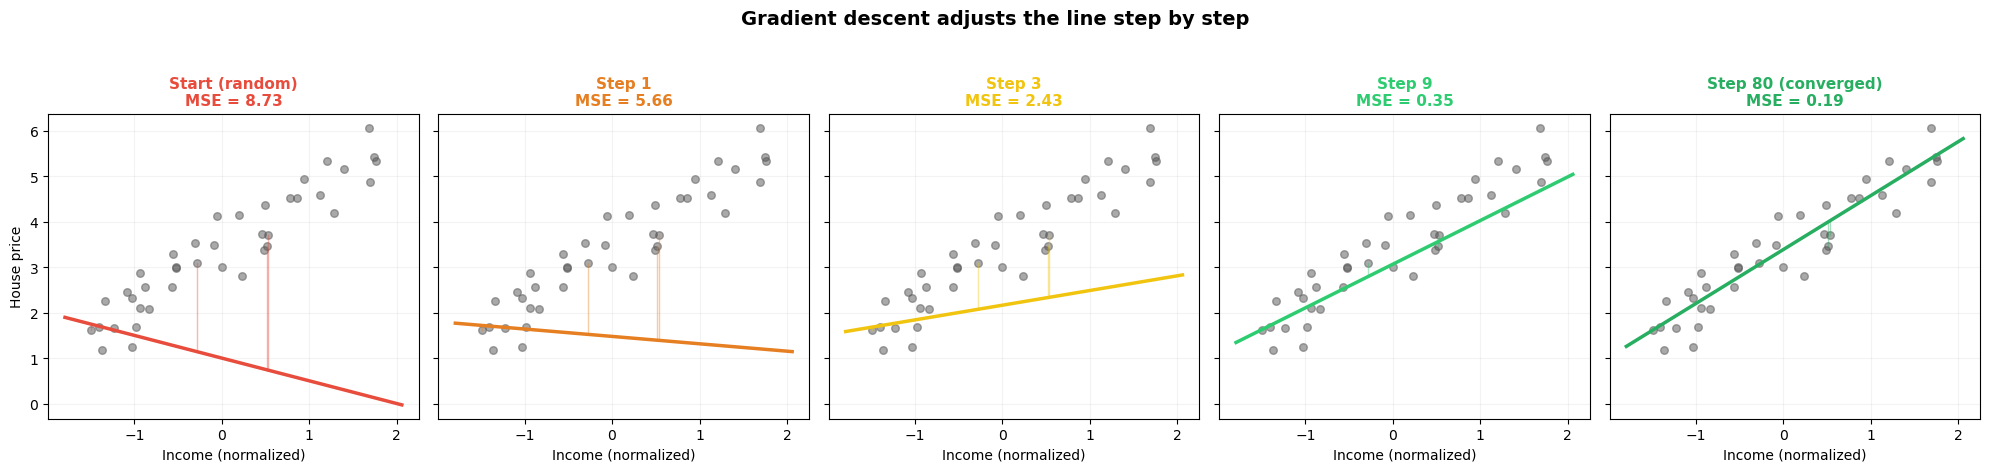

Each panel is the same data. The line starts random (high MSE) and
gradient descent tilts and shifts it until it fits the trend (low MSE).
The error lines shrink as the model improves.


In [104]:
# Watch gradient descent adjust a line through data, step by step
plot_line_fitting_intro()
plt.show()

print("Each panel is the same data. The line starts random (high MSE) and")
print("gradient descent tilts and shifts it until it fits the trend (low MSE).")
print("The error lines shrink as the model improves.")

## What Just Happened?

The line started with random weight and bias - a terrible fit with high MSE. Each step, gradient descent computed how wrong the predictions were (the **loss**), figured out which direction to tilt and shift the line (the **gradient**), and nudged it a little. After enough steps, the line settled on a good fit.

Those vertical lines between the data points and the line are the **errors**. The **loss function** (MSE) squares those errors and averages them into a single number. Gradient descent's job is to make that number as small as possible.

But how does gradient descent know *which direction* to adjust? That's where the **gradient** comes in. Let's look at that more closely on a simpler example - minimizing a curve instead of fitting a line:

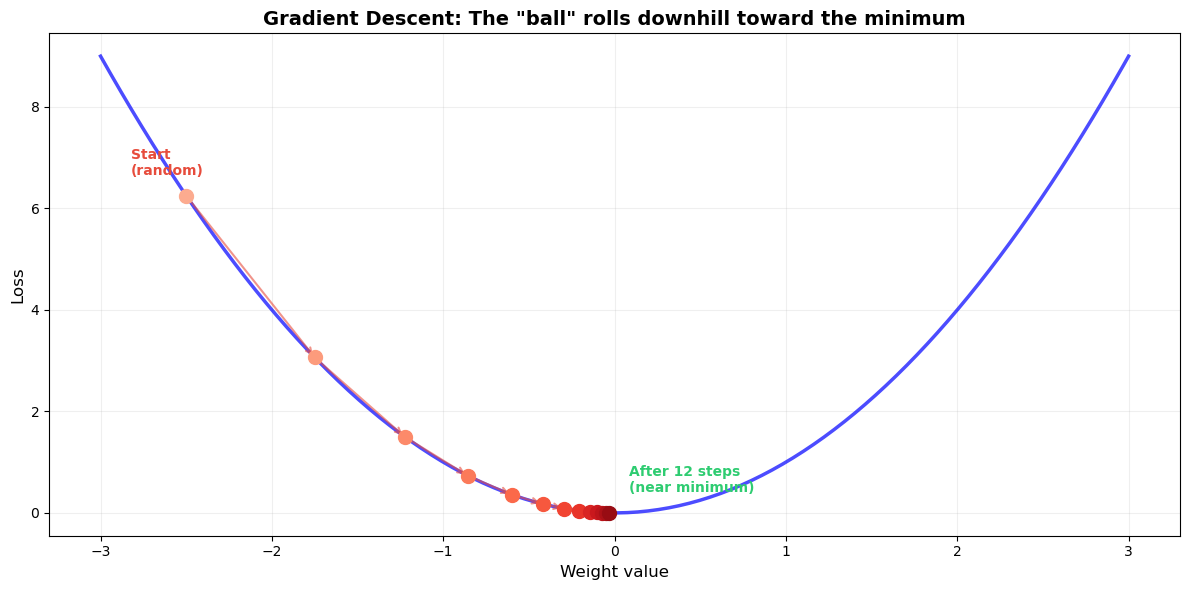

Each step: compute the slope (gradient), move opposite to it.
After 12 steps, the weight went from -2.5 to -0.035 (minimum is at 0).


In [105]:
# Gradient descent on a simple curve: watch the "ball" roll downhill
xs, ys = plot_gd_ball_rolling()
plt.show()

print("Each step: compute the slope (gradient), move opposite to it.")
print(f"After 12 steps, the weight went from {xs[0]:.1f} to {xs[-1]:.3f} (minimum is at 0).")

## Beyond a Single Line: Multiple Features

So far we've visualized gradient descent with one weight controlling the slope of one line. That's great for intuition. But real data has many columns - income, house age, number of rooms, location. Each feature gets its own weight. The prediction for one house becomes:

```
prediction = w1 * income + w2 * house_age + w3 * rooms + ... + bias
```

All those weights start as random numbers - garbage. And you can't visualize a line in 8 dimensions. But gradient descent doesn't care. It does the exact same thing: measure how wrong (loss), figure out which weight to nudge in which direction (gradient), take a small step. Whether you have 1 weight or 10,000, the process is identical.

When you have many rows and many features, this becomes matrix multiplication. Here's what it actually looks like with 3 houses and 3 features:

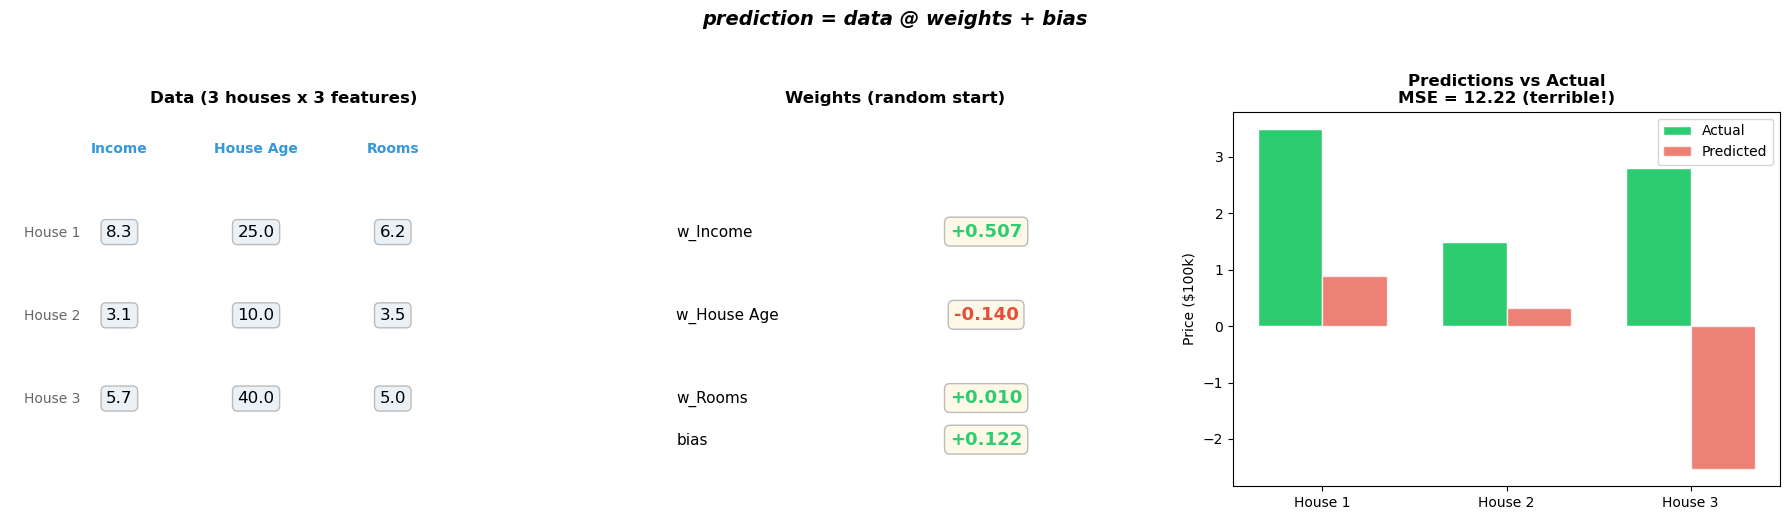

Weights: [ 0.507 -0.14   0.01 ]  (random garbage)
Bias:    0.122
MSE:     12.22

With random weights, the predictions are way off.
Gradient descent will adjust each weight to reduce this MSE - same process as the line.


In [106]:
# What does multi-feature prediction actually look like?
feature_names_intro = ['Income', 'House Age', 'Rooms']
data_intro = np.array([
    [8.3, 25, 6.2],   # House 1: high income, older, 6 rooms
    [3.1, 10, 3.5],   # House 2: low income, newer, small
    [5.7, 40, 5.0],   # House 3: medium income, old, medium
])
actual_prices_intro = np.array([3.5, 1.5, 2.8])

# Random starting weights
np.random.seed(7)
weights_intro = np.round(np.random.randn(3) * 0.3, 3)
bias_intro = np.round(np.random.randn() * 0.3, 3)

predictions_intro, mse_intro = plot_multi_feature_intro(
    data_intro, feature_names_intro, weights_intro, bias_intro, actual_prices_intro)
plt.show()

print(f"Weights: {weights_intro}  (random garbage)")
print(f"Bias:    {bias_intro}")
print(f"MSE:     {mse_intro:.2f}")
print(f"\nWith random weights, the predictions are way off.")
print(f"Gradient descent will adjust each weight to reduce this MSE - same process as the line.")

## The Training Loop

That's gradient descent. The whole thing boils down to a loop:

```
for each step:
    1. Make predictions with current weights     (forward pass)
    2. Measure how wrong they are                (loss)
    3. Figure out which direction to adjust      (gradient)
    4. Nudge the weights a little bit            (update)
```

This exact loop - with fancier models and automatic gradient computation - trains image classifiers, language models, and everything else in deep learning. The model changes. The loop doesn't. We'll build it from scratch in this notebook, first with NumPy, then with PyTorch.

## What Else Will We Cover?

Beyond the core loop, this notebook also tackles:

**Feature scaling.** If your inputs have wildly different ranges, gradient descent struggles. Standardizing inputs to a common scale fixes this. Boring but essential.

**Overfitting and underfitting.** When is a model too simple to learn the real pattern? When does it start memorizing noise instead of learning? In L2 we saw these as patterns in loss curves. Here we'll understand *why* they happen, and meet the **bias-variance tradeoff**.

**From linear to neural.** We'll push the linear model to its limits, then show that a simple neural network - using the same training loop - can learn curves instead of only straight lines. That's the bridge to L4.

## Resources

Watch these before or alongside the notebook - they cover the same concepts from different angles.

- [3Blue1Brown - Gradient Descent: How Neural Networks Learn](https://www.youtube.com/watch?v=IHZwWFHWa-w) (21 min) - outstanding visual explanation of gradient descent and loss landscapes
- [StatQuest - Linear Regression](https://www.youtube.com/watch?v=7ArmBVF2dCs) (27 min) - builds linear regression from scratch with clear visuals
- [StatQuest - Bias and Variance](https://www.youtube.com/watch?v=EuBBz3bI-aA) (7 min) - the theory behind overfitting
- [Google ML Crash Course - Linear Regression](https://developers.google.com/machine-learning/crash-course/linear-regression) - interactive, good visual explanations

## The Core Idea: Fitting a Line to Data

Here's 20,000 California housing districts. Each dot is a district - its x position is the median income, its y position is the median house value. There's clearly a relationship: richer districts have pricier homes.

Regression = finding the line (or curve) that best captures that relationship. Three attempts:

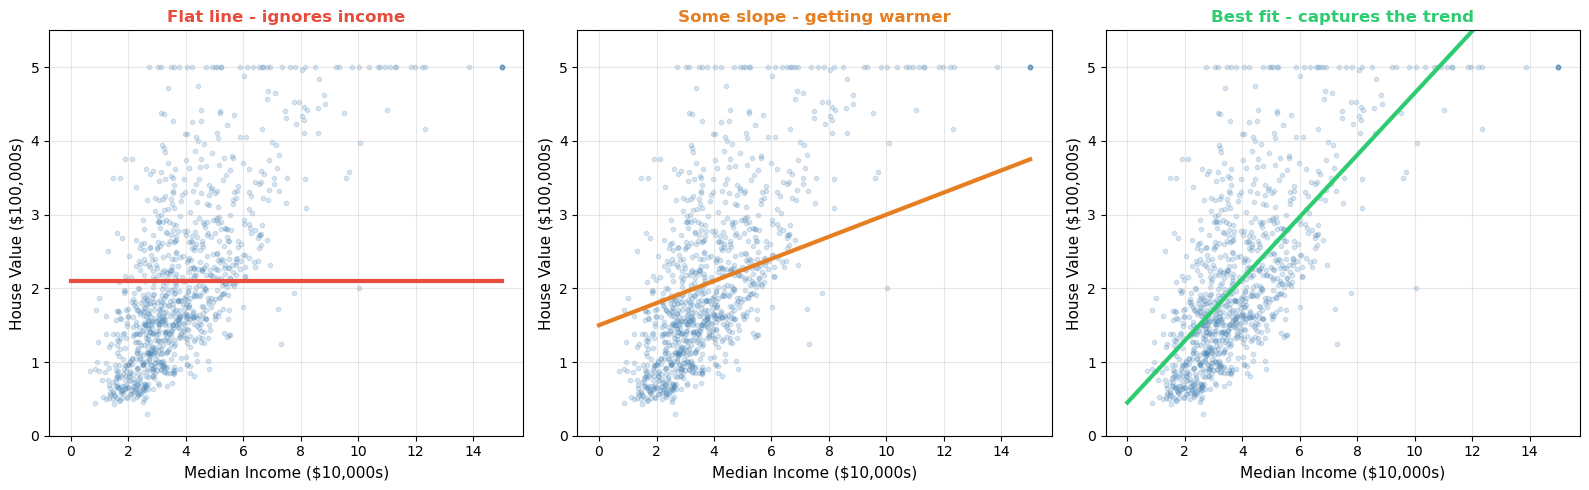

Left:   Ignores income entirely - terrible predictions
Middle: Tilted in the right direction - but still off
Right:  Captures the upward trend - the 'best fit' line


In [107]:
# Load California Housing data and show three regression attempts
from sklearn.datasets import fetch_california_housing
_housing = fetch_california_housing()
plot_regression_intro(_housing.data[:, 0], _housing.target)

print("Left:   Ignores income entirely - terrible predictions")
print("Middle: Tilted in the right direction - but still off")
print("Right:  Captures the upward trend - the 'best fit' line")

The model is just: **prediction = weight × income + bias**. That's two numbers - the slope and the intercept. The right panel found good values; the left two didn't.

The entire rest of this notebook is about answering one question: **how do we find those best values automatically?** That's where loss functions, gradients, and gradient descent come in. But first, let's set up the data properly.

## Part 1: The California Housing Dataset

We already saw the income-vs-price scatter above. Let's look at the full dataset - 20,640 districts, 8 features each. We'll start with just income as our single input, then use all 8 features later in Part 11.

In [108]:
# Load the California Housing dataset
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

print("California Housing Dataset")
print("=" * 60)
print(f"Number of districts: {len(df):,}")
print(f"Features: {list(california.feature_names)}")
print(f"\nTarget: Median House Value (in $100,000s)")
print(f"  Range: ${df['MedHouseVal'].min()*100:.0f}k - ${df['MedHouseVal'].max()*100:.0f}k")
print(f"\nWith {len(df):,} districts and {len(california.feature_names)} features,")
print("this is a real-world regression problem.")

# Show the actual data - this is what the model will learn from
df.head(8)

California Housing Dataset
Number of districts: 20,640
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target: Median House Value (in $100,000s)
  Range: $15k - $500k

With 20,640 districts and 8 features,
this is a real-world regression problem.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414


### Train/Test Split: The Golden Rule

**Never evaluate your model on the same data you trained it on.**

Why? Because a model can memorize training data perfectly but fail completely on new examples. Think of it like studying for an exam with the answer key in front of you - you'd get 100%, but it wouldn't mean you learned anything. The real test is questions you haven't seen before.

We split our data into two parts:
- **Training set** (~80%): The data the model learns from. Gradient descent uses this to adjust weights.
- **Test set** (~20%): Held back completely. The model never sees this during training. We only use it at the end to check if the model actually learned the underlying pattern or just memorized the training examples.

If the model performs well on the training set but poorly on the test set, it memorized instead of learned. That's called **overfitting**, and we'll explore it properly later in this notebook. For now, just remember: always keep some data aside that the model never touches during training.

In [109]:
# Focus on ONE feature first: median income
# This makes visualization easy and concepts clear
X = df['MedInc'].values
y = df['MedHouseVal'].values

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Total districts:  {len(X):,}")
print(f"Training set:     {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set:         {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)")
print("\nWe'll train on 16,512 districts and test on 4,128 the model has never seen.")

# Show what the data actually looks like at this point
split_df = pd.DataFrame({
    'Income (feature)': X_train[:8].round(2),
    'House Price (target)': y_train[:8],
})
print("\nFirst 8 training rows (one feature, one target):")
display(split_df)

Total districts:  20,640
Training set:     16,512 (80%)
Test set:         4,128 (20%)

We'll train on 16,512 districts and test on 4,128 the model has never seen.

First 8 training rows (one feature, one target):


,Income (feature),House Price (target)
0,3.26,1.03000
1,3.81,3.82100
2,4.16,1.72600
3,1.94,0.93400
4,3.55,0.96500
5,6.62,2.64800
6,2.52,1.57300
7,7.99,5.00001


## Part 2: Measuring "How Wrong" - The Loss Function

We found a good line by eye in the intro. But a computer can't eyeball a scatter plot. It needs a **number** that says how bad a given line is - then it can try to make that number smaller.

The natural idea: for each data point, measure the vertical distance between where the line predicts and where the point actually is. Big gaps = bad fit. Small gaps = good fit.

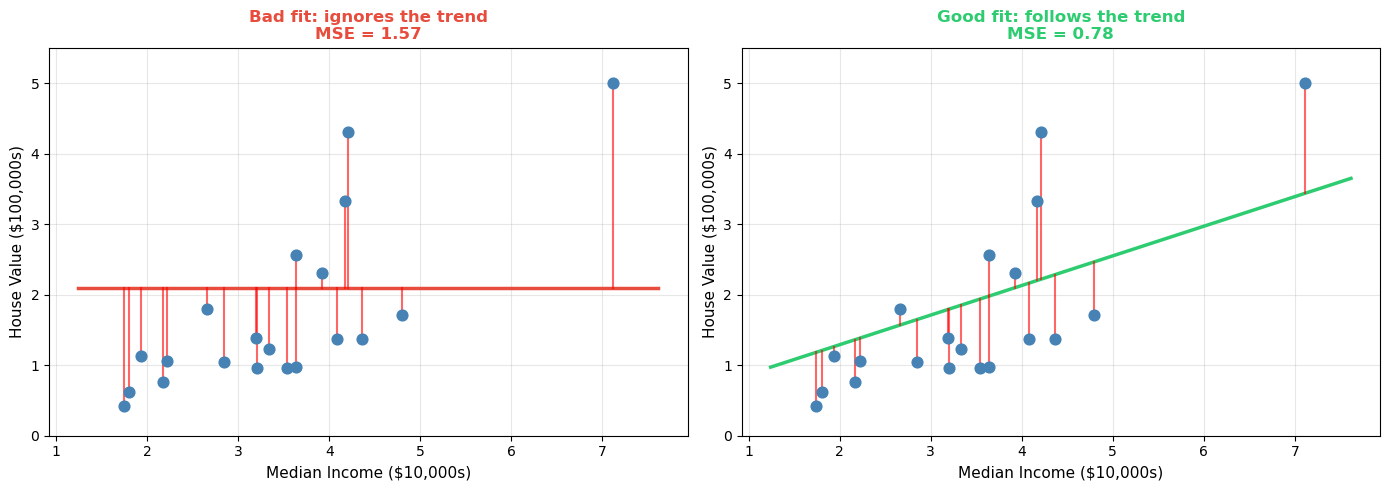

Red lines = errors. Each one is (prediction - actual) for one data point.
Bad fit MSE:  1.57 - big gaps everywhere
Good fit MSE: 0.78 - much smaller gaps


In [110]:
# Sample 20 districts so the error lines are visible
np.random.seed(42)
_idx = np.random.choice(len(X_train), 20, replace=False)
x_sample, y_sample = X_train[_idx], y_train[_idx]

fits = [
    (0.0, 2.1, 'Bad fit: ignores the trend', '#e74c3c'),
    (0.42, 0.45, 'Good fit: follows the trend', '#2ecc71'),
]
mse_bad, mse_good = plot_error_comparison(x_sample, y_sample, fits)

print("Red lines = errors. Each one is (prediction - actual) for one data point.")
print(f"Bad fit MSE:  {mse_bad:.2f} - big gaps everywhere")
print(f"Good fit MSE: {mse_good:.2f} - much smaller gaps")

Those red lines are the **errors** (also called **residuals**). We need to collapse all of them into a single number. That's the **loss function**.

For regression, the standard choice is **Mean Squared Error (MSE)**:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (\text{prediction}_i - \text{actual}_i)^2$$

Why squared? Squaring does two things: it makes all errors positive (undershooting and overshooting both count), and it punishes big misses disproportionately - predicting $300k for a $500k house is more than twice as bad as being off by $100k.

**Training = finding parameters that minimize this number.**

MSE isn't the only option. Different problems call for different loss functions: classification (Lesson 2) uses **cross-entropy** because the output is a probability, not a dollar amount. Even within regression, **MAE** (mean absolute error) treats all errors equally instead of punishing outliers. The choice of loss function shapes what the model optimizes for - but MSE is the default starting point for regression, and it's what we'll use here.

In [111]:
def predict(x, weight, bias):
    """Linear prediction: y = wx + b"""
    return weight * x + bias

def mse_loss(predictions, actual):
    """Mean Squared Error - our loss function"""
    return ((predictions - actual) ** 2).mean()

# Normalize the input features for stable gradient descent
# This is CRITICAL - we'll see why in Part 6
X_mean, X_std = X_train.mean(), X_train.std()
X_train_norm = (X_train - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

# Start with RANDOM weights - this is what every ML model does
np.random.seed(0)
random_weight = np.random.randn() * 0.5
random_bias = np.random.randn() * 0.5

print("Our model: prediction = weight x income + bias")
print(f"\nRandom starting values:")
print(f"  weight = {random_weight:.4f}  (random garbage)")
print(f"  bias   = {random_bias:.4f}  (random garbage)")

# What do predictions look like with these random weights?
random_preds = predict(X_train_norm[:6], random_weight, random_bias)
print(f"\nPredictions for first 6 districts (with random weights):")
comparison = pd.DataFrame({
    'Income (raw)': X_train[:6].round(2),
    'Actual price': y_train[:6],
    'Predicted': random_preds.round(3),
    'Error': (random_preds - y_train[:6]).round(3)
})
display(comparison)

mse_random = mse_loss(predict(X_train_norm, random_weight, random_bias), y_train)
print(f"MSE with random weights: {mse_random:.2f} (terrible)")
print(f"\nThese predictions are nonsense. Gradient descent will fix them.")

Our model: prediction = weight x income + bias

Random starting values:
  weight = 0.8820  (random garbage)
  bias   = 0.2001  (random garbage)

Predictions for first 6 districts (with random weights):


,Income (raw),Actual price,Predicted,Error
0,3.26,1.030,-0.088,-1.118
1,3.81,3.821,0.168,-3.653
2,4.16,1.726,0.328,-1.398
3,1.94,0.934,-0.698,-1.632
4,3.55,0.965,0.049,-0.916
5,6.62,2.648,1.470,-1.178


MSE with random weights: 4.21 (terrible)

These predictions are nonsense. Gradient descent will fix them.


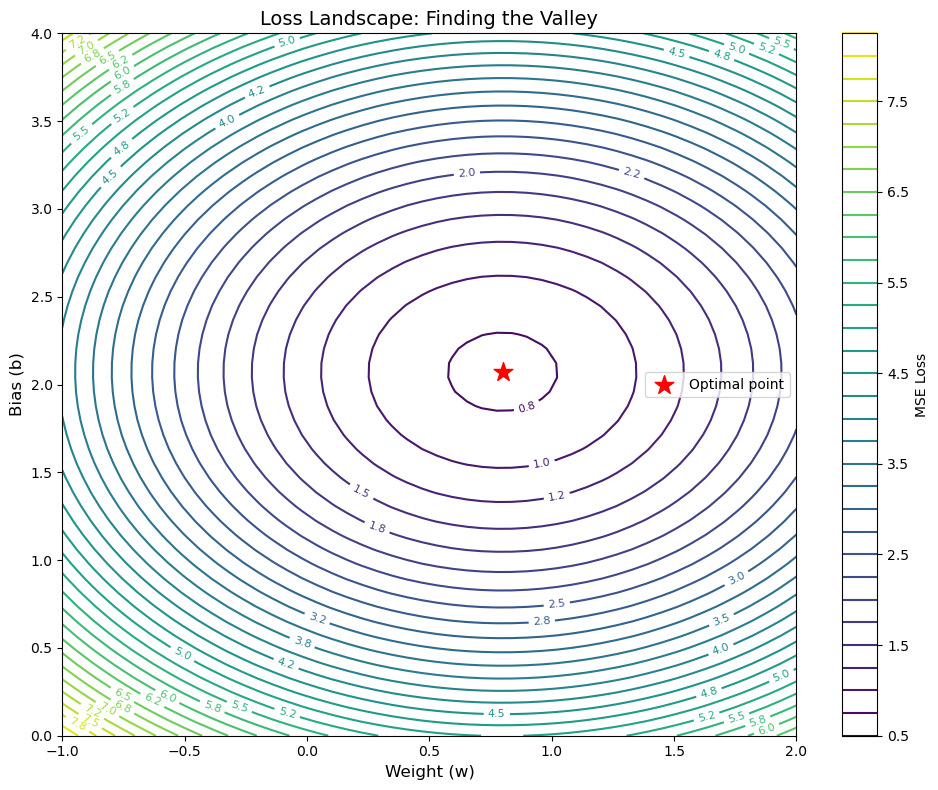

The loss surface forms a bowl shape.
Our goal: find the parameters at the bottom of this bowl!


In [112]:
# Visualize the loss for every (w, b) combination
plot_loss_landscape(X_train_norm, y_train, predict, mse_loss)

print("The loss surface forms a bowl shape.")
print("Our goal: find the parameters at the bottom of this bowl!")

### What's Actually Happening: Data x Weights = Prediction

The loss landscape above shows the MSE for every (weight, bias) combination. But what does a single prediction actually look like? Let's trace it step by step for a few districts.

Two things get multiplied together, and it's important not to mix them up:

- **Features (X)**: the input values from your dataset - income, house age, rooms. These come from the data and never change.
- **Parameters (θ)**: the weight and bias - numbers that start random and get adjusted by gradient descent. These are what the model *learns*.

In math textbooks, the parameters are often written as **θ** (theta). θ₀ is the bias, θ₁ is the weight for feature 1, θ₂ for feature 2, and so on. It's just a shorthand for "all the learnable numbers bundled together." We'll stick with `weight` and `bias` in code since it's clearer, but θ is what you'll see in papers and videos.

Training = finding the right θ so that `features x θ` gives predictions close to the actual answers.

In [113]:
# Trace the multiplication: data x weight + bias = prediction
# Using our random weights from earlier

print(f"Our random weight: {random_weight:.4f}")
print(f"Our random bias:   {random_bias:.4f}")
print()

# Show the multiplication step by step
rows = []
for i in range(5):
    x_val = X_train_norm[i]
    pred = random_weight * x_val + random_bias
    actual = y_train[i]
    error = pred - actual
    rows.append({
        'Income (norm)': round(x_val, 3),
        f'x {random_weight:.3f}': f'{x_val:.3f} x {random_weight:.3f} = {x_val * random_weight:.3f}',
        f'+ bias ({random_bias:.3f})': round(pred, 3),
        'Actual': actual,
        'Error': round(error, 3),
        'Error^2': round(error**2, 3),
    })

trace_df = pd.DataFrame(rows)
display(trace_df)

total_mse = np.mean([r['Error^2'] for r in rows])
print(f"\nMSE = mean of Error^2 column = {total_mse:.3f}")
print(f"\nEach row: take the income value, multiply by the weight, add the bias -> prediction.")
print(f"The error^2 column is what MSE averages. Gradient descent will change the weight")
print(f"and bias to make these squared errors smaller.")

Our random weight: 0.8820
Our random bias:   0.2001



,Income (norm),x 0.882,+ bias (0.200),Actual,Error,Error^2
0,-0.326,-0.326 x 0.882 = -0.288,-0.088,1.030,-1.118,1.249
1,-0.036,-0.036 x 0.882 = -0.032,0.168,3.821,-3.653,13.341
2,0.145,0.145 x 0.882 = 0.128,0.328,1.726,-1.398,1.955
3,-1.018,-1.018 x 0.882 = -0.898,-0.698,0.934,-1.632,2.662
4,-0.171,-0.171 x 0.882 = -0.151,0.049,0.965,-0.916,0.839



MSE = mean of Error^2 column = 4.009

Each row: take the income value, multiply by the weight, add the bias -> prediction.
The error^2 column is what MSE averages. Gradient descent will change the weight
and bias to make these squared errors smaller.


### Can You Find the Best Parameters by Hand?

The contour plot we made earlier shows the MSE for every (weight, bias) combination. The dark center is the valley - the best parameters live there.

Before we automate anything, try it yourself. Use the sliders below to adjust the weight and bias. The left panel shows your line on the data, the right panel shows where you are on the loss landscape. Try to get the lowest MSE you can.

In [114]:
from ipywidgets import FloatSlider, VBox, HBox, interactive_output
from IPython.display import display, Image
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg
import io

# Sample data for faster interactive plotting
sample_idx_interactive = np.random.choice(len(X_train), 800, replace=False)

# Pre-compute loss landscape grid (once, not on every slider move)
_wr = np.linspace(-1, 2, 40)
_br = np.linspace(-1, 5, 40)
_W, _B = np.meshgrid(_wr, _br)
_loss_grid = np.array([[mse_loss(predict(X_train_norm, _W[i, j], _B[i, j]), y_train)
                         for j in range(_W.shape[1])] for i in range(_W.shape[0])])

weight_slider = FloatSlider(min=-1.0, max=2.0, step=0.05, value=0.0,
    description='Weight (w):', style={'description_width': '100px'}, layout={'width': '500px'})
bias_slider = FloatSlider(min=-1.0, max=5.0, step=0.05, value=0.0,
    description='Bias (b):', style={'description_width': '100px'}, layout={'width': '500px'})

def plot_interactive_fit(w, b):
    loss = mse_loss(predict(X_train_norm, w, b), y_train)

    # OO matplotlib API - completely bypasses pyplot's figure registry and display hooks
    fig = Figure(figsize=(14, 5))
    FigureCanvasAgg(fig)
    axes = fig.subplots(1, 2)

    axes[0].scatter(X_train[sample_idx_interactive], y_train[sample_idx_interactive], alpha=0.3, s=15)
    x_line = np.linspace(X_train.min(), X_train.max(), 100)
    axes[0].plot(x_line, predict((x_line - X_mean) / X_std, w, b), 'r-', linewidth=2.5)
    axes[0].set_xlabel('Median Income ($10,000s)', fontsize=11)
    axes[0].set_ylabel('House Value ($100,000s)', fontsize=11)
    axes[0].set_title(f'w = {w:.2f}, b = {b:.2f}', fontsize=12)
    axes[0].set_ylim(-0.5, 5.5); axes[0].grid(True, alpha=0.3)

    axes[1].contourf(_W, _B, _loss_grid, levels=25, cmap='viridis', alpha=0.8)
    axes[1].scatter([w], [b], color='red', s=200, marker='X', zorder=5,
                    edgecolors='white', linewidth=2)
    axes[1].set_xlabel('Weight (w)', fontsize=11)
    axes[1].set_ylabel('Bias (b)', fontsize=11)
    axes[1].set_title(f'MSE = {loss:.4f}', fontsize=12,
                      color='green' if loss < 0.75 else 'red')
    axes[1].grid(True, alpha=0.3)
    fig.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    display(Image(data=buf.getvalue()))

out = interactive_output(plot_interactive_fit, {'w': weight_slider, 'b': bias_slider})
display(VBox([HBox([weight_slider, bias_slider]), out]))

### From Manual to Automatic

You just optimized a model by hand - tweaking two sliders until the MSE stopped going down. You probably got close to the optimal point (around w=0.80, b=2.07), but it took some fiddling.

Now imagine doing this with 8 features instead of 1. That's 9 sliders (one weight per feature plus a bias). Or a neural network with 10 million parameters. You can't hand-tune 10 million sliders.

We need an algorithm that can **automatically** walk downhill on the loss landscape until it reaches the bottom. That algorithm is **gradient descent**. But first, we need one mathematical tool: how do you figure out which direction is "downhill" at any given point?

## Part 3: Which Direction is Downhill? - The Derivative

The answer is the **derivative** (or **gradient** when you have multiple parameters). It tells you the slope of the loss at your current position - how steep the landscape is and which way it tilts.

Think about standing on a hill blindfolded. You can feel the ground sloping under your feet. That slope IS the derivative:

- **Negative slope**: The ground drops to the right - move right to go downhill
- **Positive slope**: The ground rises to the right - move left to go downhill
- **Zero slope**: You're at a flat spot - you might be at the bottom!

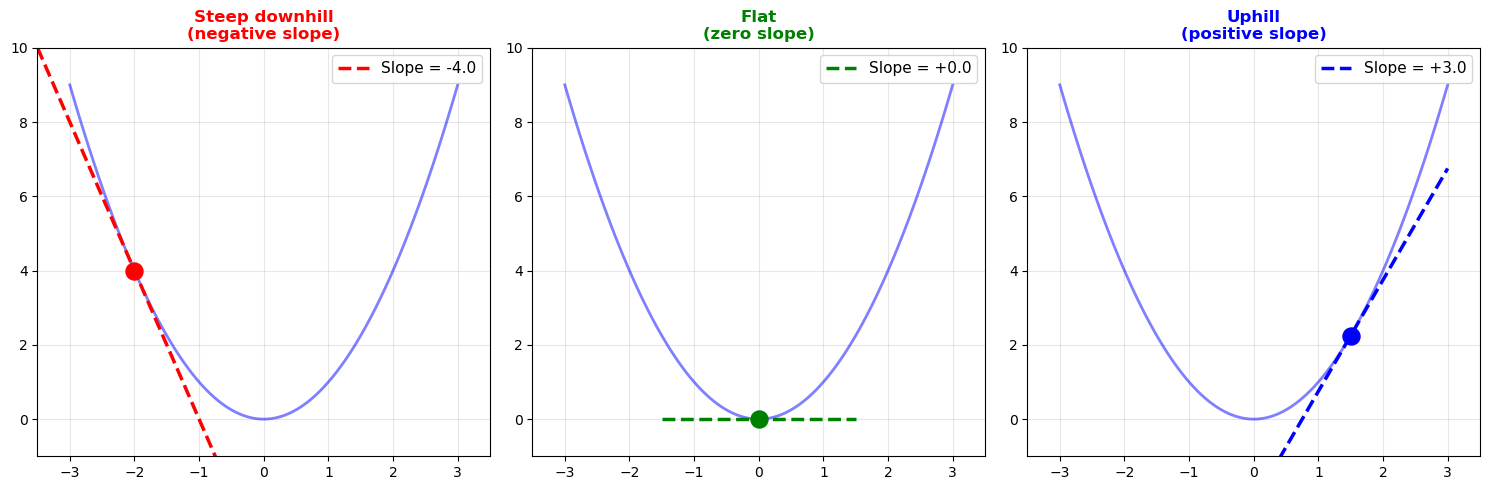

Key insight: At the MINIMUM, the slope (derivative) is zero!
The derivative tells us which direction is 'downhill'.


In [115]:
# Visual explanation: the derivative is the slope at each point
def simple_curve(x):
    return x ** 2

def derivative_of_curve(x):
    return 2 * x  # The derivative of x² is 2x

plot_derivative_visual()

print("Key insight: At the MINIMUM, the slope (derivative) is zero!")
print("The derivative tells us which direction is 'downhill'.")

### Why This Matters for Training

The derivative is how the model knows which direction to adjust its weights. When our linear model has a weight that's too high, the derivative of the loss with respect to that weight is positive - meaning "increasing this weight makes the loss worse." So we decrease it. When it's too low, the derivative is negative - "increasing this weight makes the loss better." So we increase it.

The bigger the derivative, the more confidently we know we're far from the optimum. The smaller it gets, the closer we are. That's why gradient descent naturally takes big steps at first (steep slope, large derivative) and smaller steps as it converges (flat slope, small derivative).

You don't need to compute derivatives by hand - PyTorch does it automatically. But understanding that "the derivative tells you which way to nudge each weight" is the core intuition you need. Everything else builds on this.

## Part 4: Gradient Descent - The Algorithm

Now we have everything we need. We have a loss function (MSE) that tells us how wrong we are. We have the derivative that tells us which direction is downhill. The **gradient descent** algorithm puts them together:

$$w_{\text{new}} = w_{\text{old}} - \text{learning\_rate} \times \text{gradient}$$

Let's break this down:
- **gradient**: The slope/derivative at our current position - it tells us the direction of steepest increase in the loss
- **learning_rate**: A small number (like 0.1) that controls how big of a step we take
- **minus sign**: This is crucial - the gradient points *uphill* (direction where loss increases), so we go the *opposite* way. We want to go downhill, toward lower loss.

The algorithm is almost comically simple. Start with random weights. Compute the gradient. Take a small step in the opposite direction. Repeat. That's it. There's no clever trick, no special insight - just "which way is downhill?" followed by a small step, over and over, hundreds or thousands of times. The magic is that this actually converges to good parameters.

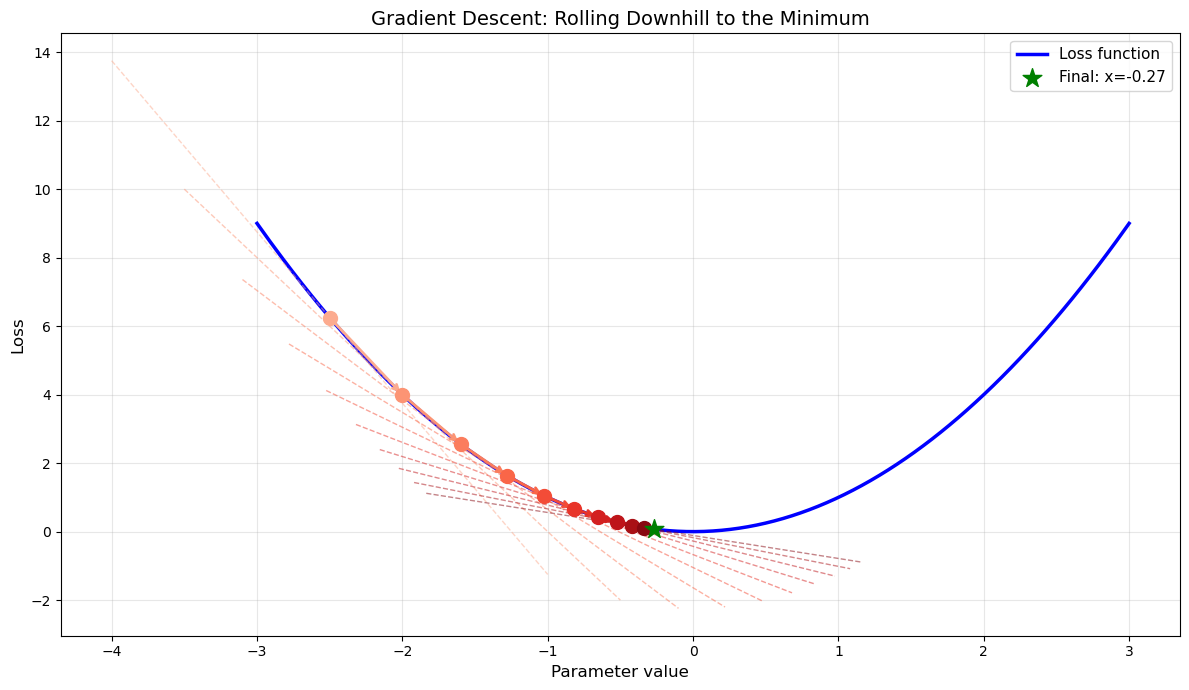

Started at x = -2.50
After 10 steps: x = -0.27

Each colored dot is one step. Dashed lines show the tangent (gradient).
The ball follows the slope downhill until it reaches the minimum!


In [116]:
# Demonstrate gradient descent on a simple parabola
fig, ax, positions = plot_gradient_descent_1d(
    f=simple_curve,
    df=derivative_of_curve,
    x_start=-2.5,
    lr=0.1,
    n_steps=10,
    x_range=(-3, 3),
    title="Gradient Descent: Rolling Downhill to the Minimum"
)
plt.show()

print(f"Started at x = {positions[0]:.2f}")
print(f"After 10 steps: x = {positions[-1]:.2f}")
print("\nEach colored dot is one step. Dashed lines show the tangent (gradient).")
print("The ball follows the slope downhill until it reaches the minimum!")

### Implement It Yourself

The visualization above shows 10 steps of gradient descent on a simple parabola. Notice how the steps get smaller as we approach the minimum - that's because the slope (gradient) gets flatter near the bottom, so each update is smaller.

Let's write those same steps as code. The actual algorithm is just 3 lines inside a loop - compute the gradient, update the position, and that's one step of gradient descent:

In [117]:
# Gradient descent in 3 lines
x_position = -2.5
learning_rate = 0.1

print(f"{'Step':>4}  {'x':>8}  {'Loss':>8}  {'Gradient':>10}")
print(f"   0  {x_position:>8.4f}  {simple_curve(x_position):>8.4f}")

for step in range(1, 11):
    gradient = derivative_of_curve(x_position)              # 1. Compute gradient
    x_position = x_position - learning_rate * gradient      # 2. Step opposite to gradient
    print(f"{step:>4}  {x_position:>8.4f}  {simple_curve(x_position):>8.4f}  {gradient:>+10.4f}")

print(f"\nFrom x = -2.50 (loss = 6.25) to x = {x_position:.4f} (loss = {simple_curve(x_position):.4f})")
print(f"Three lines: compute gradient, subtract lr × gradient, repeat.")

Step         x      Loss    Gradient
   0   -2.5000    6.2500
   1   -2.0000    4.0000     -5.0000
   2   -1.6000    2.5600     -4.0000
   3   -1.2800    1.6384     -3.2000
   4   -1.0240    1.0486     -2.5600
   5   -0.8192    0.6711     -2.0480
   6   -0.6554    0.4295     -1.6384
   7   -0.5243    0.2749     -1.3107
   8   -0.4194    0.1759     -1.0486
   9   -0.3355    0.1126     -0.8389
  10   -0.2684    0.0721     -0.6711

From x = -2.50 (loss = 6.25) to x = -0.2684 (loss = 0.0721)
Three lines: compute gradient, subtract lr × gradient, repeat.


### Scaling Up - Batch Gradient Descent in Plain English

We just did gradient descent on a single number. Real training works the same way, just with more numbers at once. Here's the whole process:

1. **Make up some weights.** One random number per feature, plus a bias. These start as garbage.
2. **Multiply every data row by those weights.** Each row gets dot-producted with the weight vector, bias added. One prediction per row. With random weights, these predictions are terrible.
3. **Measure how wrong we are.** Compare predictions to actual values, square the differences, average them. That's the MSE loss.
4. **Figure out which direction to nudge each weight.** That's the gradient. For each weight: "if I increase this, does the loss go up or down?"
5. **Nudge the weights.** Subtract a small fraction of the gradient from each weight.
6. **Repeat from step 2.** Each round, predictions get less terrible. After a few hundred rounds, the weights converge.

Let's walk through each step with real data and real numpy code.

In [118]:
# 3 districts x 3 features - just enough to see the pattern
demo_feature_names = ['MedInc', 'HouseAge', 'AveRooms']
X_demo_raw = df[demo_feature_names].values[:3]
y_demo = y[:3]
X_demo = (X_demo_raw - X_demo_raw.mean(axis=0)) / X_demo_raw.std(axis=0)

# Show the actual data as a table
print("The data (3 districts, 3 features each):")
data_df = pd.DataFrame(X_demo_raw, columns=demo_feature_names)
data_df['House Price (target)'] = y_demo
data_df.index = [f'District {i+1}' for i in range(3)]
display(data_df)

print("After standardization (centered at 0, spread of ~1):")
scaled_df = pd.DataFrame(X_demo.round(3), columns=demo_feature_names)
scaled_df.index = [f'District {i+1}' for i in range(3)]
display(scaled_df)

# Step 1: Make up random weights - one per feature, plus a bias
np.random.seed(99)
weights_demo = np.random.randn(3) * 0.3
bias_demo = np.random.randn() * 0.3

print("Random starting weights:")
weights_df = pd.DataFrame({
    'Feature': demo_feature_names + ['bias'],
    'Weight (random)': list(weights_demo.round(4)) + [round(bias_demo, 4)],
})
display(weights_df)

# Compute predictions: data @ weights + bias
predictions_demo = X_demo @ weights_demo + bias_demo

print("Predictions with random weights:")
pred_df = pd.DataFrame({
    'Actual price': y_demo,
    'Predicted': predictions_demo.round(4),
    'Error': (predictions_demo - y_demo).round(4),
}, index=[f'District {i+1}' for i in range(3)])
display(pred_df)

mse_demo = ((predictions_demo - y_demo) ** 2).mean()
print(f"MSE = {mse_demo:.4f} (terrible - random weights produce garbage predictions)")

The data (3 districts, 3 features each):


,MedInc,HouseAge,AveRooms,House Price (target)
District 1,8.3252,41.0,6.984127,4.526
District 2,8.3014,21.0,6.238137,3.585
District 3,7.2574,52.0,8.288136,3.521


After standardization (centered at 0, spread of ~1):


,MedInc,HouseAge,AveRooms
District 1,0.731,0.234,-0.22
District 2,0.683,-1.325,-1.10
District 3,-1.414,1.091,1.32


Random starting weights:


,Feature,Weight (random)
0,MedInc,-0.0427
1,HouseAge,0.6172
2,AveRooms,0.0850
3,bias,0.3989


Predictions with random weights:


,Actual price,Predicted,Error
District 1,4.526,0.4934,-4.0326
District 2,3.585,-0.5413,-4.1263
District 3,3.521,1.2448,-2.2762


MSE = 12.8233 (terrible - random weights produce garbage predictions)


**Step 2: Multiply every row by the weights.** Each row gets multiplied with the weight vector using a **dot product**, and the bias is added.

A dot product is simple: multiply each pair of numbers and add them up. If a row has features `[income, age, rooms]` and the weights are `[w1, w2, w3]`, the dot product is `income x w1 + age x w2 + rooms x w3`. That's it - multiply pairs, sum. Add the bias at the end and you have a prediction. This is the core operation in linear models, and later in every layer of a neural network.

In Python, the `@` operator does this for all rows at once. Let's expand one row to see what's happening inside:

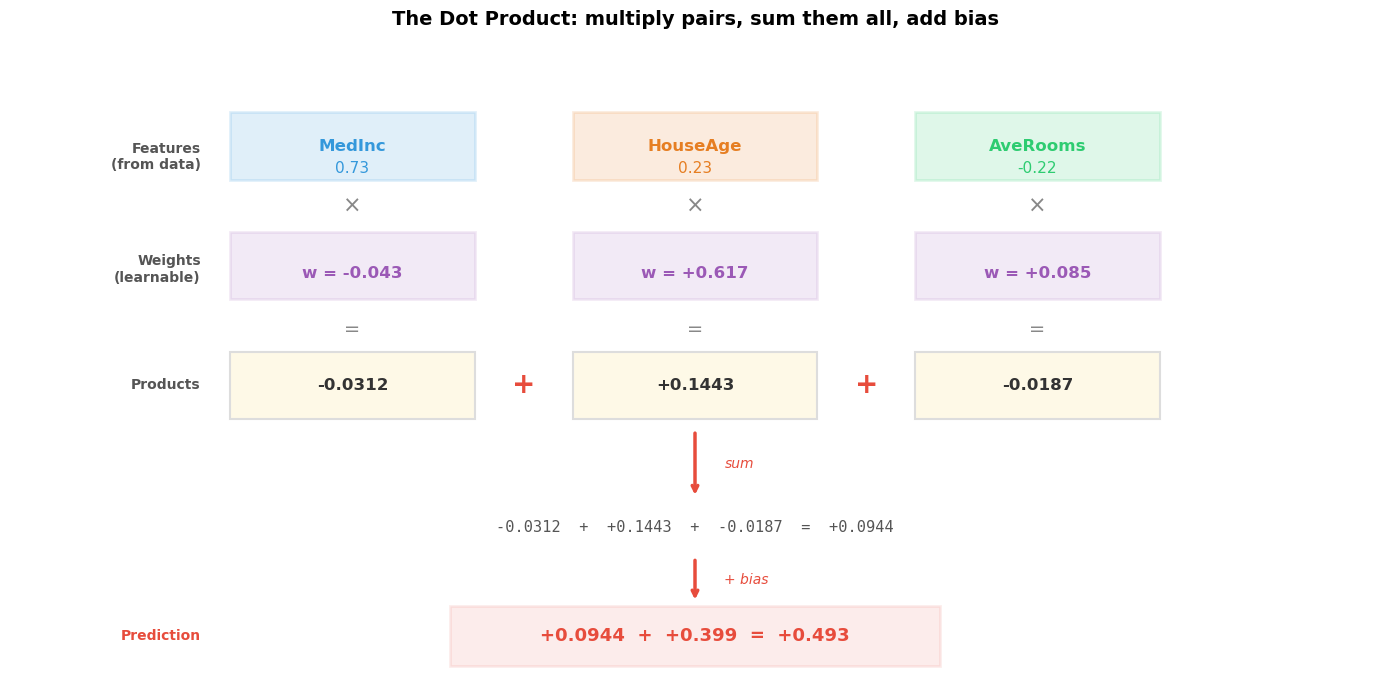

This is what happens for ONE row. The @ operator repeats this for every row in the dataset.


In [119]:
# Visualize the dot product for one row of data
plot_dot_product(demo_feature_names, X_demo[0], weights_demo, bias_demo)
plt.show()

print("This is what happens for ONE row. The @ operator repeats this for every row in the dataset.")

In [120]:
# Expand what happens for row 1 - the dot product
row = X_demo[0]
print("Row 1 features:", np.round(row, 3))
print("Weights:       ", np.round(weights_demo, 3))
print()

terms = []
total = 0
for j, name in enumerate(demo_feature_names):
    product = row[j] * weights_demo[j]
    total += product
    terms.append(f"({row[j]:+.2f} × {weights_demo[j]:+.3f}) = {product:+.4f}")
    print(f"  {name:10s}:  {row[j]:+.2f}  ×  {weights_demo[j]:+.3f}  =  {product:+.4f}")

total += bias_demo
print(f"  {'bias':10s}:  + {bias_demo:.3f}")
print(f"  {'prediction':10s}:  = {total:+.4f}")
print(f"\nThat's one dot product. The @ operator does this for all {len(X_demo)} rows at once:")
print()

# All rows at once
predictions_demo = X_demo @ weights_demo + bias_demo
print("predictions = X_demo @ weights_demo + bias_demo")
print(f"predictions = {np.round(predictions_demo, 4)}")
print(f"actual      = {np.round(y_demo, 4)}")

Row 1 features: [ 0.731  0.234 -0.22 ]
Weights:        [-0.043  0.617  0.085]

  MedInc    :  +0.73  ×  -0.043  =  -0.0312
  HouseAge  :  +0.23  ×  +0.617  =  +0.1443
  AveRooms  :  -0.22  ×  +0.085  =  -0.0187
  bias      :  + 0.399
  prediction:  = +0.4934

That's one dot product. The @ operator does this for all 3 rows at once:

predictions = X_demo @ weights_demo + bias_demo
predictions = [ 0.4934 -0.5413  1.2448]
actual      = [4.526 3.585 3.521]


**Step 3: Measure how wrong we are.** Now we compare each prediction to the actual house price. Subtract actual from predicted to get the error for each row. Some errors are positive (we predicted too high), some negative (too low). We square them all and take the mean - that's the MSE loss. One number that summarizes how wrong the model is across all rows.

Here's the full picture - weights multiplied with every row, producing predictions, then compared against actual values:

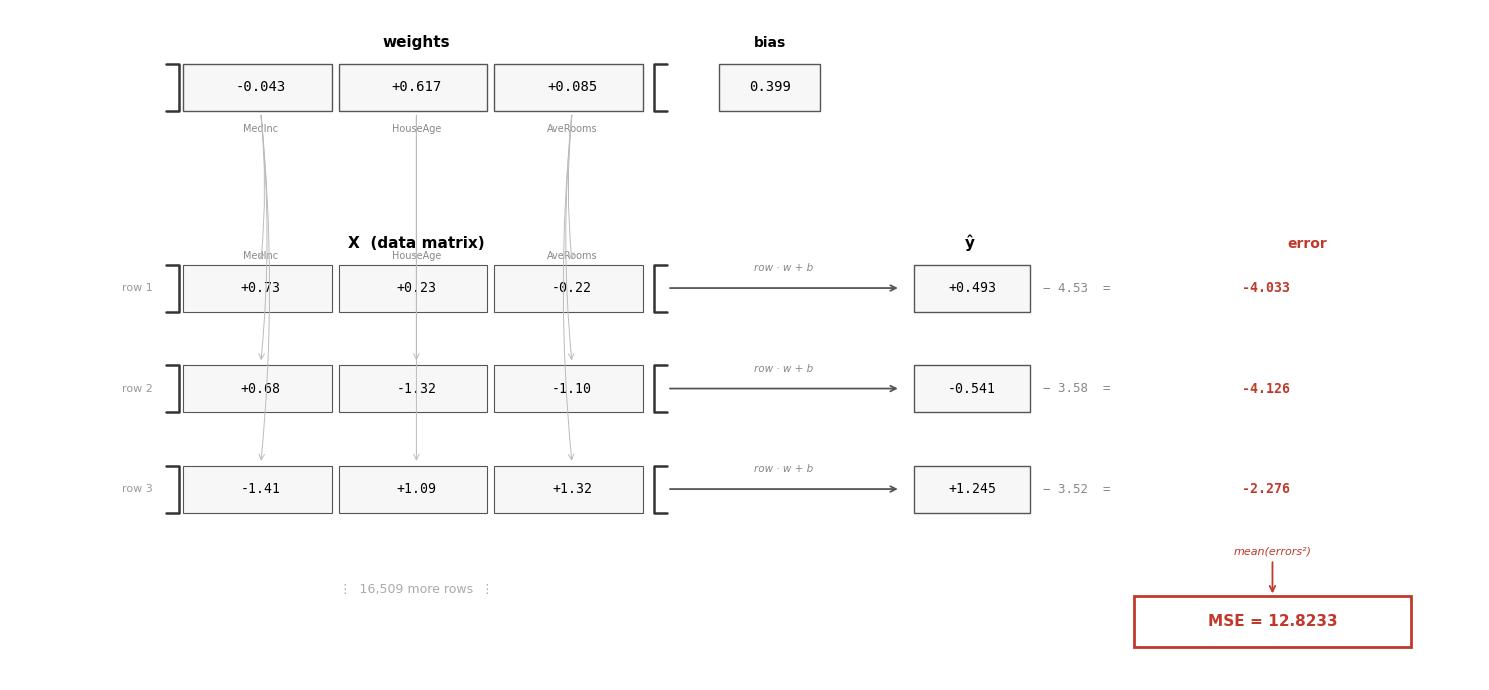

errors = predictions - actual = [-4.0326 -4.1263 -2.2762]
MSE    = mean(errors²)        = 12.8233

With random weights, we're way off. Now: which direction should we nudge each weight?


In [121]:
# The diagram: weights × data rows → predictions → errors
draw_batch_gd_diagram(
    X_demo, y_demo, weights_demo, bias_demo, demo_feature_names, n_total_rows=len(X_train)
)

# Compute the loss
errors_demo = predictions_demo - y_demo
loss_before = (errors_demo ** 2).mean()

print(f"errors = predictions - actual = {np.round(errors_demo, 4)}")
print(f"MSE    = mean(errors²)        = {loss_before:.4f}")
print(f"\nWith random weights, we're way off. Now: which direction should we nudge each weight?")

**Step 4: Compute the gradients.** The gradient tells us, for each weight: "if I increase this weight slightly, does the loss go up or down, and by how much?"

The formula is `grad_w = (2/n) * (X.T @ errors)`. The key operation is `X.T @ errors` - it transposes the data matrix and multiplies by the error vector. This computes how much each feature contributed to the errors across all rows simultaneously.

In [122]:
n = len(y_demo)
grad_w = (2/n) * (X_demo.T @ errors_demo)
grad_b = (2/n) * errors_demo.sum()

print("grad_w = (2/n) * (X.T @ errors)")
print(f"grad_w = {np.round(grad_w, 4)}")
print(f"grad_b = {grad_b:.4f}\n")

# What does each gradient mean?
for j, name in enumerate(demo_feature_names):
    direction = "decrease" if grad_w[j] > 0 else "increase"
    print(f"  w_{name:8s} gradient = {grad_w[j]:+.4f}  →  {direction} this weight to reduce loss")
print(f"  bias       gradient = {grad_b:+.4f}")

grad_w = (2/n) * (X.T @ errors)
grad_w = [-1.6983  1.3603  1.614 ]
grad_b = -6.9568

  w_MedInc   gradient = -1.6983  →  increase this weight to reduce loss
  w_HouseAge gradient = +1.3603  →  decrease this weight to reduce loss
  w_AveRooms gradient = +1.6140  →  decrease this weight to reduce loss
  bias       gradient = -6.9568


**Step 5: Nudge the weights.** This is the actual update. We subtract a fraction of the gradient from each weight. That fraction is the **learning rate** - it controls how big of a step we take. A small learning rate means cautious steps, a large one means aggressive jumps.

After updating, we re-run the forward pass with the new weights to verify the loss actually dropped. If it did, great - one step of gradient descent worked. Now repeat this hundreds of times.

In [123]:
lr = 0.1
new_weights = weights_demo - lr * grad_w
new_bias = bias_demo - lr * grad_b

# Show the update as a table: old weight, gradient, new weight
update_df = pd.DataFrame({
    'Old weight': list(weights_demo.round(4)) + [round(bias_demo, 4)],
    'Gradient': list(grad_w.round(4)) + [round(grad_b, 4)],
    f'- {lr} x gradient': list((lr * grad_w).round(4)) + [round(lr * grad_b, 4)],
    'New weight': list(new_weights.round(4)) + [round(new_bias, 4)],
}, index=demo_feature_names + ['bias'])
print(f"Weight update (learning rate = {lr}):")
display(update_df)

# Verify: re-run forward pass with updated weights
new_predictions = X_demo @ new_weights + new_bias
new_errors = new_predictions - y_demo
loss_after = (new_errors ** 2).mean()

# Show before vs after predictions
compare_df = pd.DataFrame({
    'Actual': y_demo,
    'Before (random)': predictions_demo.round(4),
    'After (1 step)': new_predictions.round(4),
    'Error before': (predictions_demo - y_demo).round(4),
    'Error after': new_errors.round(4),
}, index=[f'District {i+1}' for i in range(3)])
print("\nPredictions before and after one gradient descent step:")
display(compare_df)

print(f"\nMSE: {mse_demo:.4f} -> {loss_after:.4f}")
print(f"Loss dropped by {mse_demo - loss_after:.4f} in just ONE step!")
print(f"\nNow imagine doing this hundreds of times...")

Weight update (learning rate = 0.1):


,Old weight,Gradient,- 0.1 x gradient,New weight
MedInc,-0.0427,-1.6983,-0.1698,0.1271
HouseAge,0.6172,1.3603,0.1360,0.4811
AveRooms,0.0850,1.6140,0.1614,-0.0764
bias,0.3989,-6.9568,-0.6957,1.0946



Predictions before and after one gradient descent step:


,Actual,Before (random),After (1 step),Error before,Error after
District 1,4.526,0.4934,1.3168,-4.0326,-3.2092
District 2,3.585,-0.5413,0.6281,-4.1263,-2.9569
District 3,3.521,1.2448,1.3389,-2.2762,-2.1821



MSE: 12.8233 -> 7.9345
Loss dropped by 4.8888 in just ONE step!

Now imagine doing this hundreds of times...


### Batch vs. Stochastic Gradient Descent

What we just saw is **batch gradient descent**: compute the gradient using **every row**, then update once. The gradient is exact but can be slow with millions of rows.

| Variant | Rows per update | Gradient quality | Speed per step |
|---------|----------------|-----------------|----------------|
| **Batch GD** | All N rows | Exact | Slow |
| **Mini-batch SGD** | 32-256 rows | Good enough | Fast |
| **SGD** (pure) | 1 random row | Noisy | Very fast |

**Mini-batch SGD** is what frameworks like PyTorch use by default. Instead of computing `X.T @ errors` over all 16,000 rows, you grab a random batch of 64 rows, compute the gradient from just those, and update. The gradient is noisier but you get 250x more updates per pass through the data.

For our small dataset, batch GD works perfectly. For training image classifiers or language models on millions of examples, mini-batch SGD is the only practical option.

## Part 5: The Learning Rate - Step Size Matters!

The **learning rate** is a number you pick before training starts (a **hyperparameter** - remember those from L2?). It controls how much the weights change on each gradient descent step. This sounds like a small detail, but it might be the single most impactful setting in all of machine learning.

- **Too small** (e.g. 0.001): Each step barely moves the weights. The model will eventually converge, but it might take thousands of iterations to get there. In practice, you run out of patience or compute budget before it finishes.
- **Too large** (e.g. 0.9): Each step overshoots the minimum. Instead of settling into the valley, the model bounces from one side to the other, and the loss might actually get *worse* over time. In extreme cases, the loss explodes to infinity and training fails completely.
- **Just right** (e.g. 0.1): Smooth, steady progress. The loss drops quickly at first, then gradually levels off as the weights approach their optimal values.

There's no formula for the perfect learning rate - it depends on the data, the model, and the loss landscape. You experiment. The visualizations below let you see this directly:

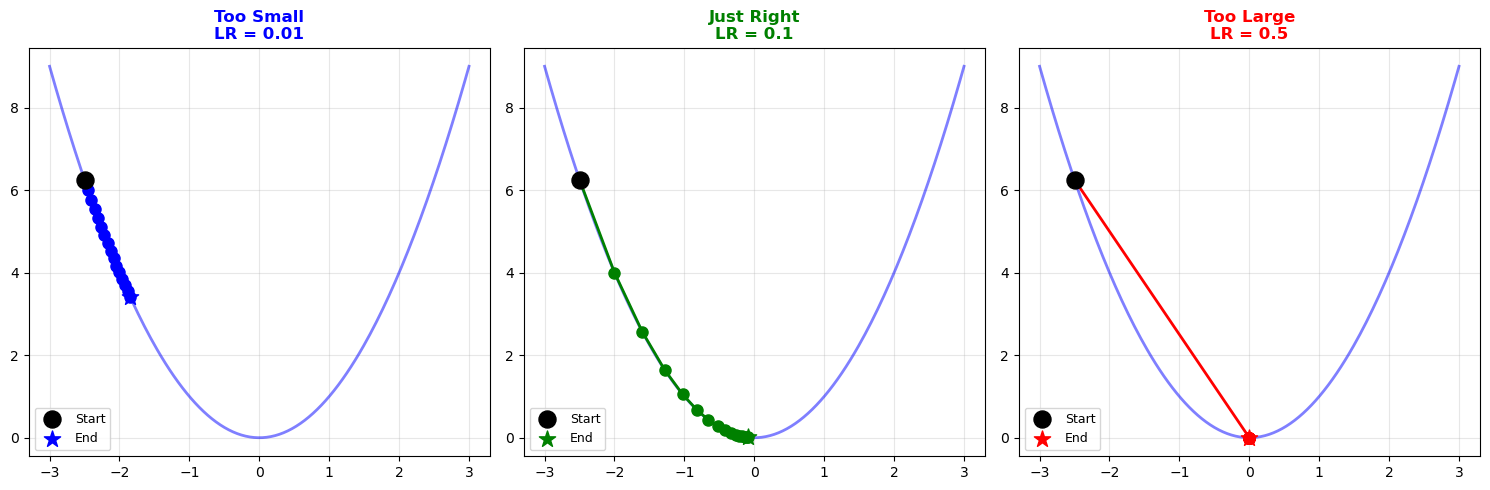

LEFT (lr=0.01):  Too slow - barely moves after 15 steps
MIDDLE (lr=0.1): Just right - smooth convergence to minimum
RIGHT (lr=0.5):  Too fast - overshoots and bounces around


In [124]:
fig, axes = plot_learning_rate_comparison(
    f=simple_curve,
    df=derivative_of_curve,
    x_start=-2.5,
    learning_rates=[0.01, 0.1, 0.5],
    n_steps=15,
    x_range=(-3, 3)
)
plt.show()

print("LEFT (lr=0.01):  Too slow - barely moves after 15 steps")
print("MIDDLE (lr=0.1): Just right - smooth convergence to minimum")
print("RIGHT (lr=0.5):  Too fast - overshoots and bounces around")

### Explore It Yourself

The three plots above show hand-picked learning rates. What happens at 0.3? At 0.05? Use the sliders below to find the sweet spot - and watch what happens when you push it too far.

In [125]:
from ipywidgets import FloatSlider, IntSlider, HBox, VBox, interactive_output
from IPython.display import display, Image
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg
import io

lr_slider = FloatSlider(min=0.01, max=0.95, step=0.01, value=0.1,
    description='Learning Rate:', style={'description_width': '120px'}, layout={'width': '500px'})
steps_slider = IntSlider(min=1, max=40, step=1, value=15,
    description='Steps:', style={'description_width': '120px'}, layout={'width': '500px'})

def explore_learning_rate(lr, n_steps):
    x_vals = np.linspace(-3, 3, 200)

    fig = Figure(figsize=(14, 5))
    FigureCanvasAgg(fig)
    ax_path, ax_loss = fig.subplots(1, 2)

    # Left: GD path on parabola
    ax_path.plot(x_vals, simple_curve(x_vals), 'b-', linewidth=2, alpha=0.5)
    x_current = -2.5
    path_x = [x_current]
    path_loss = [simple_curve(x_current)]
    diverged = False
    for _ in range(n_steps):
        gradient = derivative_of_curve(x_current)
        x_current = x_current - lr * gradient
        if abs(x_current) > 10:
            diverged = True
            break
        path_x.append(x_current)
        path_loss.append(simple_curve(x_current))

    final_loss = path_loss[-1]
    color = '#e74c3c' if diverged or final_loss > 1.0 else '#2ecc71'
    ax_path.plot(path_x, path_loss, 'o-', color=color, markersize=6, linewidth=1.5)
    ax_path.scatter([path_x[0]], [path_loss[0]], color='black', s=120, zorder=5, label='Start')
    ax_path.scatter([path_x[-1]], [path_loss[-1]], color=color, s=150, zorder=5, marker='*', label='End')
    ax_path.set_xlim(-3.5, 3.5)
    ax_path.set_ylim(-0.5, 10)
    ax_path.set_xlabel('x', fontsize=11)
    ax_path.set_ylabel('Loss = x²', fontsize=11)
    status = 'DIVERGED!' if diverged else f'Final loss: {final_loss:.4f}'
    ax_path.set_title(f'GD Path  (lr={lr:.2f}, {len(path_x)-1} steps)\n{status}',
                       fontsize=11, fontweight='bold', color=color)
    ax_path.legend(fontsize=9)
    ax_path.grid(True, alpha=0.3)

    # Right: Loss over steps
    ax_loss.plot(range(len(path_loss)), path_loss, 'o-', color=color, markersize=5, linewidth=2)
    ax_loss.set_xlabel('Step', fontsize=11)
    ax_loss.set_ylabel('Loss', fontsize=11)
    ax_loss.set_title('Loss Over Steps', fontsize=11, fontweight='bold')
    ax_loss.grid(True, alpha=0.3)
    ax_loss.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    display(Image(data=buf.getvalue()))

out = interactive_output(explore_learning_rate, {'lr': lr_slider, 'n_steps': steps_slider})
display(VBox([HBox([lr_slider, steps_slider]), out]))

## Part 6: Feature Scaling - Why We Normalized the Data

In Part 2, we quietly normalized the income data before computing the loss. Now that we understand gradient descent and learning rates, we can see why that step was essential.

The raw income feature ranges from 0.5 to 15. The gradient formula multiplies errors by the feature values, so the weight gradient ends up roughly 10x larger than the bias gradient. A learning rate that works for one is wrong for the other - and this distorts the entire loss landscape that GD has to navigate:

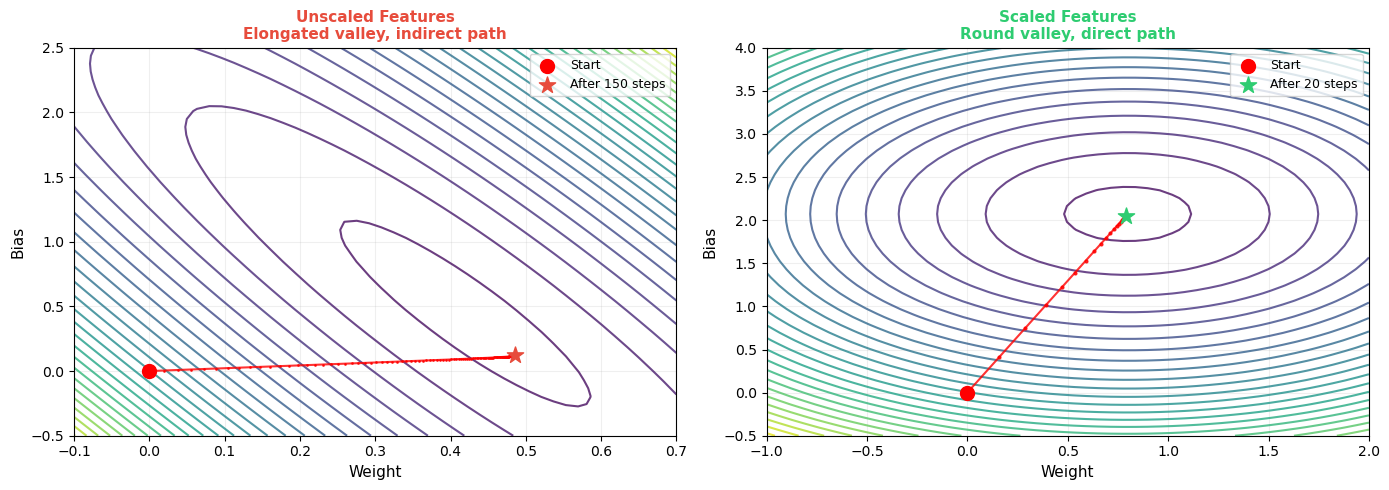

Left:  Unscaled - the valley is stretched. GD crawls along the narrow direction.
Right: Scaled - the valley is round. GD heads straight to the minimum.

150 steps (lr=0.001) vs 20 steps (lr=0.1) to reach the same quality.


In [126]:
# How feature scaling changes the loss landscape
plot_scaling_landscape(X_train, X_train_norm, y_train, predict, mse_loss)

print("Left:  Unscaled - the valley is stretched. GD crawls along the narrow direction.")
print("Right: Scaled - the valley is round. GD heads straight to the minimum.")
print(f"\n150 steps (lr=0.001) vs 20 steps (lr=0.1) to reach the same quality.")

### Standardization in Code

The formula is straightforward:

$$x_{\text{scaled}} = \frac{x - \text{mean}}{\text{std}}$$

We did this manually in Part 2 with numpy. In practice, scikit-learn's `StandardScaler` does the same math - but it also **remembers** the training statistics so you can apply the exact same transformation to test data or new inputs later.

In [127]:
# What does standardization actually do to the data?
from sklearn.preprocessing import StandardScaler

# Show raw vs normalized values side by side
scaling_df = pd.DataFrame({
    'Income (raw)': X_train[:8].round(2),
    'Income (normalized)': X_train_norm[:8].round(3),
})
print("Raw vs normalized - first 8 districts:")
display(scaling_df)

print(f"\nRaw income range:        {X_train.min():.1f} to {X_train.max():.1f}")
print(f"Normalized income range: {X_train_norm.min():.2f} to {X_train_norm.max():.2f}")
print(f"Normalized mean: {X_train_norm.mean():.6f}  std: {X_train_norm.std():.4f}")
print(f"\nAfter standardization, the data is centered around 0 with a spread of ~1.")
print(f"This makes gradient descent much happier - all features on the same scale.")

# scikit-learn's StandardScaler does the same thing
scaler_demo = StandardScaler()
X_scaler_result = scaler_demo.fit_transform(X_train.reshape(-1, 1)).flatten()

print(f"\nManual:        (X - mean) / std")
print(f"StandardScaler: scaler.fit_transform(X)")
print(f"Same result:    {np.allclose(X_train_norm, X_scaler_result)}")
print(f"\nStandardScaler also remembers the mean/std so you can apply the exact")
print(f"same transformation to test data later. We'll use it in future lessons.")

Raw vs normalized - first 8 districts:


,Income (raw),Income (normalized)
0,3.26,-0.326
1,3.81,-0.036
2,4.16,0.145
3,1.94,-1.018
4,3.55,-0.171
5,6.62,1.440
6,2.52,-0.715
7,7.99,2.158



Raw income range:        0.5 to 15.0
Normalized income range: -1.78 to 5.84
Normalized mean: -0.000000  std: 1.0000

After standardization, the data is centered around 0 with a spread of ~1.
This makes gradient descent much happier - all features on the same scale.

Manual:        (X - mean) / std
StandardScaler: scaler.fit_transform(X)
Same result:    True

StandardScaler also remembers the mean/std so you can apply the exact
same transformation to test data later. We'll use it in future lessons.


### The Impact on Gradient Descent

Standardization is simple math. But does it actually matter in practice? Let's run the same gradient descent algorithm three ways and compare convergence:

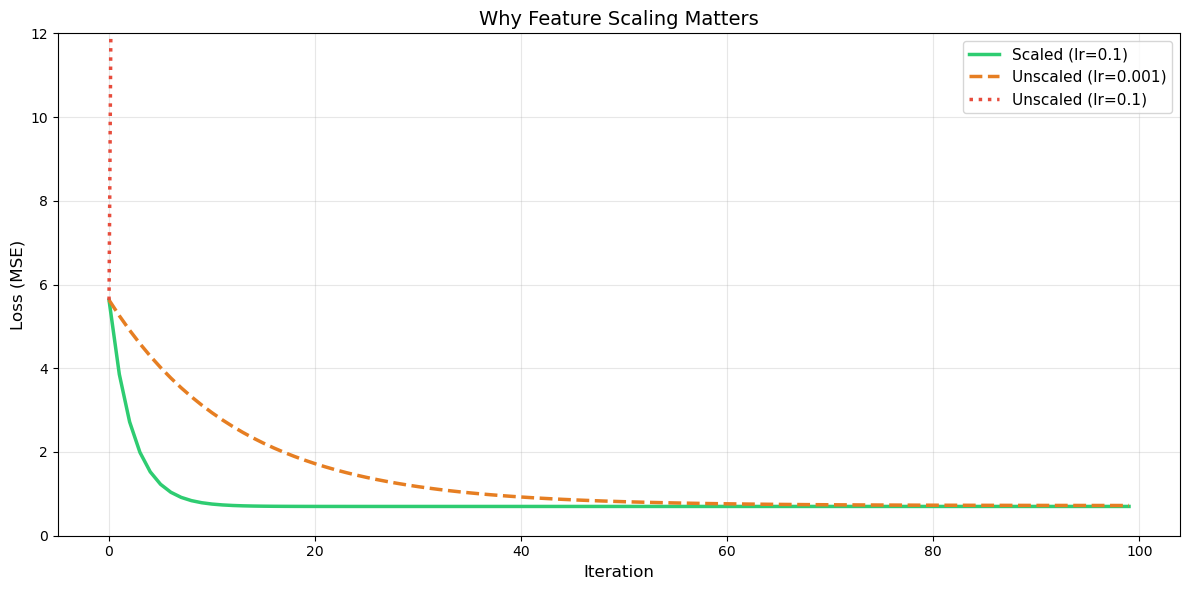

Green:  Scaled data + good lr     → converges in ~20 iterations
Orange: Unscaled data + tiny lr   → converges, but 100x slower
Red:    Unscaled data + same lr   → DIVERGES - gradients explode

Without scaling, you either crawl or crash. There's no good learning rate.


In [128]:
# Run gradient descent on raw vs normalized features - same algorithm, same initial params
configs = [
    ('Scaled (lr=0.1)', X_train_norm, 0.1, '#2ecc71', '-'),
    ('Unscaled (lr=0.001)', X_train, 0.001, '#e67e22', '--'),
    ('Unscaled (lr=0.1)', X_train, 0.1, '#e74c3c', ':'),
]
plot_scaling_convergence(configs, y_train, predict, mse_loss)

print("Green:  Scaled data + good lr     → converges in ~20 iterations")
print("Orange: Unscaled data + tiny lr   → converges, but 100x slower")
print("Red:    Unscaled data + same lr   → DIVERGES - gradients explode")
print("\nWithout scaling, you either crawl or crash. There's no good learning rate.")

## Part 7: Training on Real Data

We've explored the loss landscape with sliders, implemented gradient descent on a toy parabola, and walked through batch gradient descent step by step with 3 districts. Now it's time to put it all together: train on the full California Housing dataset with 16,512 training rows.

### What Happens in One Epoch

An **epoch** is one complete pass through all the training data. In batch gradient descent, each epoch follows the same cycle we've been building up to:

1. **Forward pass**: Take all 16,512 rows, multiply each by the current weight, add the bias. That's 16,512 predictions - all computed using the same weight and bias via the dot product.
2. **Loss**: Compare all 16,512 predictions to actual prices, compute MSE. One number that says how wrong we are.
3. **Gradient**: Using those errors, compute how much the weight and bias should change. The gradient formula averages across all rows, so it reflects the overall direction of improvement.
4. **Update**: Nudge the weight and bias by a small step in the opposite direction of the gradient.

Then we go back to step 1 - but now the weight and bias are slightly different. The dot product produces slightly better predictions. The loss is slightly lower. The gradient is slightly smaller. Repeat for 200 epochs, and the model converges.

The gradient formulas for linear regression with MSE loss are:

$$\frac{\partial \text{Loss}}{\partial w} = \frac{2}{n} \sum (\text{prediction} - \text{actual}) \cdot x$$

$$\frac{\partial \text{Loss}}{\partial b} = \frac{2}{n} \sum (\text{prediction} - \text{actual})$$

The weight gradient multiplies errors by the feature values - features that contributed more to the error get larger corrections. The bias gradient is just the average error.

In [129]:
def compute_gradients(X, y, weight, bias):
    """Compute gradients for weight and bias"""
    predictions = predict(X, weight, bias)
    errors = predictions - y
    n = len(y)
    
    gradient_weight = (2 / n) * (errors * X).sum()
    gradient_bias = (2 / n) * errors.sum()
    
    return gradient_weight, gradient_bias

# Initialize with RANDOM parameters (same as every ML model)
np.random.seed(42)
weight = np.random.randn() * 0.5
bias = np.random.randn() * 0.5
learning_rate = 0.1
n_iterations = 200

print(f"Starting weights (random):")
print(f"  weight = {weight:.4f}")
print(f"  bias   = {bias:.4f}")
print(f"  MSE    = {mse_loss(predict(X_train_norm, weight, bias), y_train):.4f}")
print(f"\nRunning {n_iterations} iterations of gradient descent (lr={learning_rate})...\n")

# Track history for visualization
loss_history = []
weight_history = [weight]
bias_history = [bias]

# THE TRAINING LOOP
for i in range(n_iterations):
    grad_w, grad_b = compute_gradients(X_train_norm, y_train, weight, bias)
    weight -= learning_rate * grad_w
    bias -= learning_rate * grad_b
    
    current_loss = mse_loss(predict(X_train_norm, weight, bias), y_train)
    loss_history.append(current_loss)
    weight_history.append(weight)
    bias_history.append(bias)
    
    # Show progress at key moments
    if i in [0, 1, 4, 9, 19, 49, 99, 199]:
        print(f"  Step {i+1:>3d}:  weight = {weight:+.4f}  bias = {bias:.4f}  MSE = {current_loss:.4f}")

print(f"\nFinal weights (after gradient descent):")
print(f"  weight = {weight:.4f}")
print(f"  bias   = {bias:.4f}")
print(f"  MSE    = {loss_history[-1]:.4f}")

# Show before/after predictions
print(f"\nBefore vs after - first 6 districts:")
before_preds = predict(X_train_norm[:6], weight_history[0], bias_history[0])
after_preds = predict(X_train_norm[:6], weight, bias)
comparison = pd.DataFrame({
    'Actual': y_train[:6],
    'Before (random)': before_preds.round(3),
    'After (trained)': after_preds.round(3),
    'Error (before)': (before_preds - y_train[:6]).round(3),
    'Error (after)': (after_preds - y_train[:6]).round(3),
})
display(comparison)

Starting weights (random):
  weight = 0.2484
  bias   = -0.0691
  MSE    = 5.5860

Running 200 iterations of gradient descent (lr=0.1)...

  Step   1:  weight = +0.3584  bias = 0.3591  MSE = 3.8268
  Step   2:  weight = +0.4464  bias = 0.7017  MSE = 2.7008
  Step   5:  weight = +0.6182  bias = 1.3704  MSE = 1.2239
  Step  10:  weight = +0.7394  bias = 1.8421  MSE = 0.7555
  Step  20:  weight = +0.7922  bias = 2.0473  MSE = 0.6998
  Step  50:  weight = +0.7985  bias = 2.0719  MSE = 0.6991
  Step 100:  weight = +0.7985  bias = 2.0719  MSE = 0.6991
  Step 200:  weight = +0.7985  bias = 2.0719  MSE = 0.6991

Final weights (after gradient descent):
  weight = 0.7985
  bias   = 2.0719
  MSE    = 0.6991

Before vs after - first 6 districts:


,Actual,Before (random),After (trained),Error (before),Error (after)
0,1.030,-0.150,1.811,-1.180,0.781
1,3.821,-0.078,2.043,-3.899,-1.778
2,1.726,-0.033,2.187,-1.759,0.461
3,0.934,-0.322,1.259,-1.256,0.325
4,0.965,-0.112,1.935,-1.077,0.970
5,2.648,0.288,3.222,-2.360,0.574


In [ ]:
# Trace a few epochs in detail: same 3 districts, watch predictions improve
sample_idx = [0, 1, 2]
trace_epochs = [1, 5, 10, 50, 200]

rows = []
for epoch in trace_epochs:
    w = weight_history[epoch]
    b = bias_history[epoch]
    preds = predict(X_train_norm[sample_idx], w, b)
    for j, idx in enumerate(sample_idx):
        rows.append({
            'Epoch': epoch,
            'District': f'#{idx+1}',
            'Weight': round(w, 4),
            'Bias': round(b, 4),
            'Prediction': round(preds[j], 3),
            'Actual': y_train[idx],
            'Error': round(preds[j] - y_train[idx], 3),
        })

trace_df = pd.DataFrame(rows)
print("The same 3 districts at different epochs - watch the predictions improve:\n")
for epoch in trace_epochs:
    epoch_df = trace_df[trace_df['Epoch'] == epoch][['District', 'Weight', 'Bias', 'Prediction', 'Actual', 'Error']]
    print(f"Epoch {epoch}:")
    display(epoch_df.reset_index(drop=True))
    print()

Notice what's happening across epochs: the weight and bias are the same for all 3 districts within each epoch (they're shared parameters), but they change from epoch to epoch as gradient descent adjusts them. The predictions start terrible (epoch 1) and gradually converge toward the actual values. The errors shrink. That's the training loop doing its job - each epoch brings the weights a little closer to their optimal values.

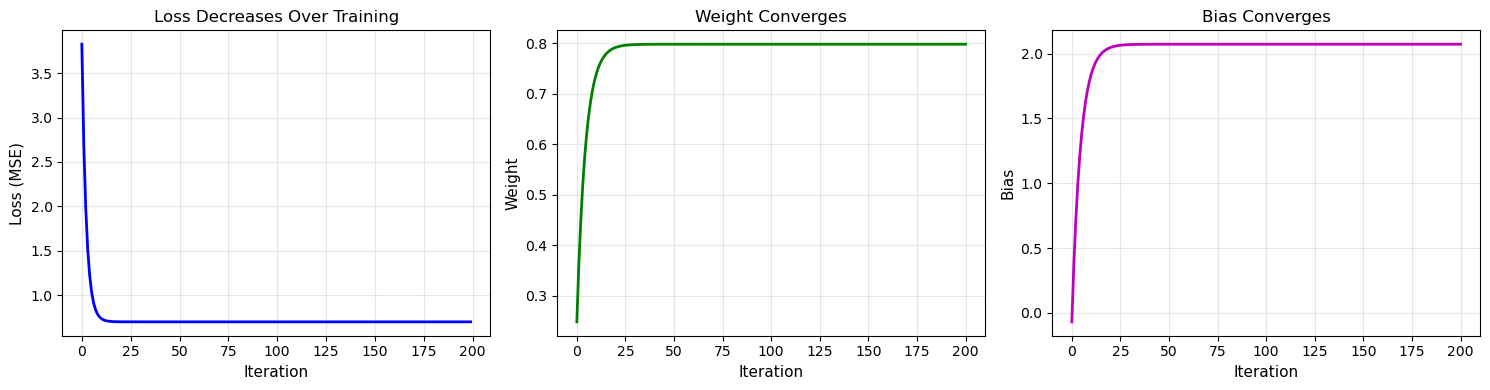

All parameters stabilize as we approach the minimum loss.


In [130]:
# Visualize the training progress
plot_training_progress(loss_history, weight_history, bias_history)

print("All parameters stabilize as we approach the minimum loss.")

### Experiment with Training

How does the learning rate affect real data training? What if we stop too early? Slide the values and watch the loss curve and fitted line change in real time.

In [131]:
from ipywidgets import FloatSlider, IntSlider, HBox, VBox, interactive_output
from IPython.display import display, Image
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg
import io

train_lr_slider = FloatSlider(min=0.01, max=1.0, step=0.01, value=0.1,
    description='Learning Rate:', style={'description_width': '120px'}, layout={'width': '450px'})
train_iters_slider = IntSlider(min=5, max=500, step=5, value=200,
    description='Iterations:', style={'description_width': '120px'}, layout={'width': '450px'})

def explore_training(lr, n_iters):
    w_train, b_train = 0.0, 0.0
    n = len(X_train_norm)
    losses = []

    for iteration in range(n_iters):
        current_predictions = predict(X_train_norm, w_train, b_train)
        errors = current_predictions - y_train
        w_train -= lr * (2/n) * (errors * X_train_norm).sum()
        b_train -= lr * (2/n) * errors.sum()
        losses.append(mse_loss(current_predictions, y_train))
        if losses[-1] > 1e6:
            break

    fig = Figure(figsize=(14, 5))
    FigureCanvasAgg(fig)
    ax_loss, ax_fit = fig.subplots(1, 2)

    # Left: Loss curve
    if max(losses) < 1e6:
        ax_loss.plot(losses, 'b-', linewidth=2)
        ax_loss.set_ylabel('MSE Loss', fontsize=11)
        if len(losses) > 1:
            ax_loss.set_ylim(0, max(losses[0] * 1.1, losses[-1] * 2))
    else:
        ax_loss.text(0.5, 0.5, 'DIVERGED!\nLearning rate too high',
                     transform=ax_loss.transAxes, ha='center', va='center',
                     fontsize=16, color='red', fontweight='bold')
    ax_loss.set_xlabel('Iteration', fontsize=11)
    ax_loss.set_title(f'Training Loss  (lr={lr:.2f}, {n_iters} iters)', fontsize=11, fontweight='bold')
    ax_loss.grid(True, alpha=0.3)

    # Right: Fitted line
    sample_rng = np.random.RandomState(42)
    sample_idx = sample_rng.choice(len(X_train), 800, replace=False)
    ax_fit.scatter(X_train[sample_idx], y_train[sample_idx], alpha=0.3, s=15, color='steelblue')
    x_line = np.linspace(X_train.min(), X_train.max(), 100)
    y_line = predict((x_line - X_mean) / X_std, w_train, b_train)
    ax_fit.plot(x_line, y_line, 'r-', linewidth=2.5)
    ax_fit.set_xlabel('Median Income ($10,000s)', fontsize=11)
    ax_fit.set_ylabel('House Value ($100,000s)', fontsize=11)
    final_loss = losses[-1] if losses[-1] < 1e6 else float('inf')
    ax_fit.set_title(f'w={w_train:.3f}, b={b_train:.3f}, MSE={final_loss:.4f}',
                     fontsize=11, fontweight='bold')
    ax_fit.set_ylim(-0.5, 5.5)
    ax_fit.grid(True, alpha=0.3)

    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    display(Image(data=buf.getvalue()))

out = interactive_output(explore_training, {'lr': train_lr_slider, 'n_iters': train_iters_slider})
display(VBox([HBox([train_lr_slider, train_iters_slider]), out]))

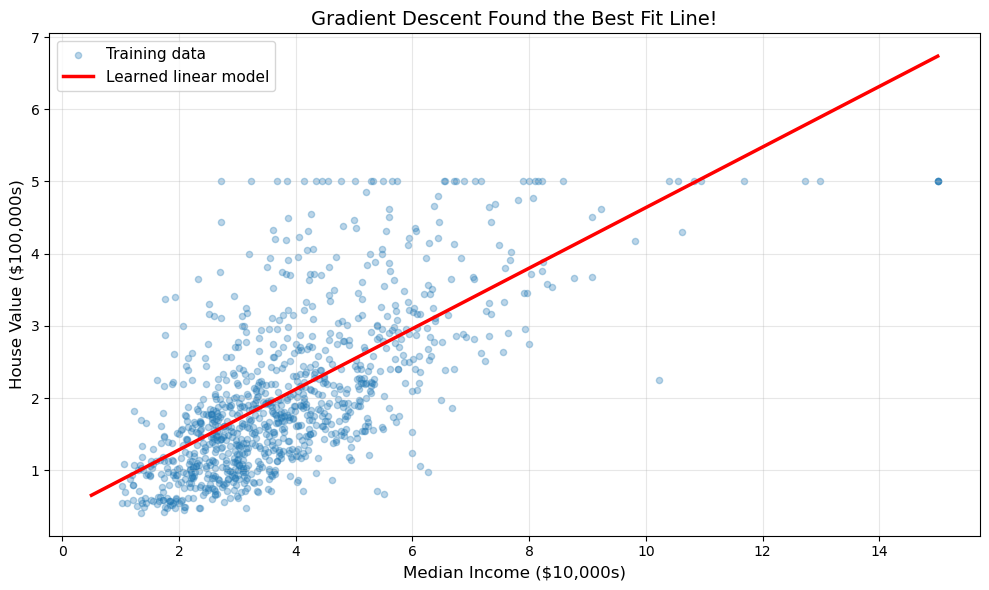

Final model (on normalized inputs): y = 0.799 × x_norm + 2.072
Where x_norm = (income - 3.88) / 1.90


In [132]:
# Visualize the learned model on the data
plot_model_fit(X_train, y_train, X_mean, X_std, weight, bias, predict)

print(f"Final model (on normalized inputs): y = {weight:.3f} × x_norm + {bias:.3f}")
print(f"Where x_norm = (income - {X_mean:.2f}) / {X_std:.2f}")

### The Practical Shortcut

We wrote gradient descent from scratch to understand the mechanics. For linear regression specifically, scikit-learn can solve it in one step - no iterations, no learning rate to tune:

In [133]:
# Everything we just did in 200 iterations, solved in 1 line
from sklearn.linear_model import LinearRegression

sklearn_lr = LinearRegression()
sklearn_lr.fit(X_train_norm.reshape(-1, 1), y_train)

print("scikit-learn LinearRegression (closed-form solution):")
print(f"  Weight: {sklearn_lr.coef_[0]:.4f}  (our gradient descent: {weight:.4f})")
print(f"  Bias:   {sklearn_lr.intercept_:.4f}  (our gradient descent: {bias:.4f})")
print(f"\nIdentical answers. sklearn uses the 'normal equation' - direct linear algebra.")
print(f"So why learn gradient descent? Because neural networks have no closed-form")
print(f"solution. Gradient descent is the only way to train them.")

scikit-learn LinearRegression (closed-form solution):
  Weight: 0.7985  (our gradient descent: 0.7985)
  Bias:   2.0719  (our gradient descent: 2.0719)

Identical answers. sklearn uses the 'normal equation' - direct linear algebra.
So why learn gradient descent? Because neural networks have no closed-form
solution. Gradient descent is the only way to train them.


### The Training Loop - A Universal Pattern

What we just wrote is THE core training loop that powers all of machine learning:

```python
for each epoch:
    predictions = model(inputs)               # Forward pass (dot product)
    loss = loss_function(predictions, targets) # How wrong?
    gradients = compute_gradients()            # Which direction?
    parameters -= learning_rate * gradients    # Nudge weights
```

This same pattern - with more complex models and automatic gradient computation - trains image classifiers, language models, speech recognition, and everything else in deep learning. The model changes. The training loop doesn't.

Let that sink in. We just built, from scratch, the same algorithm that trains GPT, image classifiers, and self-driving car models. Our model was a simple line with 2 parameters. GPT has billions. But the loop is identical:

1. Make predictions with current weights (forward pass - the dot product)
2. Measure how wrong they are (loss)
3. Compute which direction each weight should move (gradients)
4. Nudge the weights a tiny bit (update)
5. Go back to step 1 with the updated weights - that's the next epoch

### Epochs and Iterations

We ran 200 **epochs** above - 200 complete passes through all 16,512 training rows. In batch gradient descent, each epoch = one weight update, because we look at every row before updating.

Remember the `epoch` column from Lesson 2's `fine_tune()` output? Same concept. But fastai used **mini-batch SGD**, which works differently: instead of looking at all rows before updating, you grab a small batch (e.g. 64 rows), compute the gradient from just those, and update immediately. Then grab the next 64 rows, update again. One epoch still means one complete pass through the data, but now it involves many weight updates per epoch (~250 updates for 16k rows with batch size 64).

Mini-batch SGD is what PyTorch uses by default. We'll switch to it in later lessons. For now, batch gradient descent keeps things simple - one epoch, one update, easy to trace.

## Part 8: From Scratch to PyTorch

We've been computing gradients by hand - writing out the formulas for the weight and bias gradients, implementing them in NumPy. This was important for understanding, but nobody does this in practice. The math gets complicated fast when you have more than a simple linear model.

**PyTorch** solves this with **automatic differentiation** (autograd). You define the model and the loss function, and PyTorch figures out all the gradients for you. No manual calculus. The training loop looks almost identical to what we wrote - forward pass, compute loss, backward pass, update - but the backward pass is a single line: `loss.backward()`.

This is the framework you'll use for the rest of the course, so pay attention to the pattern. Let's verify that PyTorch arrives at the same answer as our hand-coded version:

In [134]:
import torch
import torch.nn as nn

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_norm).reshape(-1, 1)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)

# Create a simple linear model
model = nn.Linear(1, 1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# PyTorch initialized random weights for us - let's see them
print("PyTorch's random starting weights:")
print(f"  weight = {model.weight.data.item():.4f}")
print(f"  bias   = {model.bias.data.item():.4f}")
print(f"  (different random seed than our NumPy version, but same idea)")

# Train for same number of iterations
pytorch_losses = []
for i in range(200):
    # Forward pass
    predictions = model(X_train_tensor)
    loss = loss_fn(predictions, y_train_tensor)
    
    # Backward pass + update (PyTorch computes gradients automatically!)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    pytorch_losses.append(loss.item())

print(f"\nAfter 200 steps of gradient descent:")
print(f"  weight = {model.weight.data.item():.4f}  (our NumPy version: {weight:.4f})")
print(f"  bias   = {model.bias.data.item():.4f}  (our NumPy version: {bias:.4f})")
print(f"  MSE    = {pytorch_losses[-1]:.4f}  (our NumPy version: {loss_history[-1]:.4f})")
print(f"\nSame answer. PyTorch just computed the gradients automatically instead of us")
print(f"writing the gradient formulas by hand. The training loop is identical.")

PyTorch's random starting weights:
  weight = 0.4560
  bias   = -0.3009
  (different random seed than our NumPy version, but same idea)

After 200 steps of gradient descent:
  weight = 0.7985  (our NumPy version: 0.7985)
  bias   = 2.0719  (our NumPy version: 2.0719)
  MSE    = 0.6991  (our NumPy version: 0.6991)

Same answer. PyTorch just computed the gradients automatically instead of us
writing the gradient formulas by hand. The training loop is identical.


## Part 9: Evaluation - How Good is Our Model?

Whether we train from scratch or use PyTorch, we converge to the same parameters. But matching weights doesn't tell us if the model is actually useful. How well does it predict house values it's never seen?

Different metrics answer this from different angles:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MSE** | mean((pred - actual)²) | Average squared error |
| **RMSE** | √MSE | Same units as target |
| **MAE** | mean(\|pred - actual\|) | Average absolute error |
| **R²** | 1 - SS_res/SS_tot | Proportion of variance explained |

R² is especially intuitive: R²=0.5 means the model explains 50% of the variance in house values.

In [135]:
def compute_metrics(y_true, y_pred):
    """Compute all regression metrics"""
    errors = y_pred - y_true
    
    mse = (errors ** 2).mean()
    rmse = np.sqrt(mse)
    mae = np.abs(errors).mean()
    
    ss_residual = (errors ** 2).sum()
    ss_total = ((y_true - y_true.mean()) ** 2).sum()
    r2 = 1 - (ss_residual / ss_total)
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

# Evaluate on both train and test sets
train_predictions = predict(X_train_norm, weight, bias)
test_predictions = predict(X_test_norm, weight, bias)

train_metrics = compute_metrics(y_train, train_predictions)
test_metrics = compute_metrics(y_test, test_predictions)

# Show metrics as a clean table
metrics_df = pd.DataFrame({
    'Train': train_metrics,
    'Test': test_metrics,
}).round(4)
print("Model evaluation:")
display(metrics_df)

# Show some actual predictions on test data
eval_df = pd.DataFrame({
    'Income': X_test[:10].round(2),
    'Actual Price': y_test[:10],
    'Predicted': test_predictions[:10].round(3),
    'Error': (test_predictions[:10] - y_test[:10]).round(3),
})
print("\nFirst 10 test predictions:")
display(eval_df)

print(f"\nR² = {test_metrics['R²']:.4f} means the model explains {test_metrics['R²']*100:.1f}% of the variance in house prices.")
print(f"RMSE = {test_metrics['RMSE']:.4f} means predictions are off by ~${test_metrics['RMSE']*100:.0f}k on average.")
print(f"\nTrain and test metrics are similar - no overfitting (good sign).")

Model evaluation:


,Train,Test
MSE,0.6991,0.7091
RMSE,0.8361,0.8421
MAE,0.6250,0.6299
R²,0.4770,0.4589



First 10 test predictions:


,Income,Actual Price,Predicted,Error
0,1.68,0.47700,1.150,0.673
1,2.53,0.45800,1.506,1.048
2,3.48,5.00001,1.904,-3.096
3,5.74,2.18600,2.851,0.665
4,3.72,2.78000,2.007,-0.773
5,4.71,1.58700,2.422,0.835
6,5.08,1.98200,2.576,0.594
7,3.69,1.57500,1.992,0.417
8,4.80,3.40000,2.459,-0.941
9,8.11,4.46600,3.847,-0.619



R² = 0.4589 means the model explains 45.9% of the variance in house prices.
RMSE = 0.8421 means predictions are off by ~$84k on average.

Train and test metrics are similar - no overfitting (good sign).


In [136]:
# In practice, use scikit-learn's built-in metrics:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Same metrics via scikit-learn:")
print(f"  MSE:  {mean_squared_error(y_test, test_predictions):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, test_predictions)):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, test_predictions):.4f}")
print(f"  R²:   {r2_score(y_test, test_predictions):.4f}")
print(f"\nMatches our hand-coded compute_metrics(). Understanding the math matters,")
print(f"but in production you'd use these one-liners.")

Same metrics via scikit-learn:
  MSE:  0.7091
  RMSE: 0.8421
  MAE:  0.6299
  R²:   0.4589

Matches our hand-coded compute_metrics(). Understanding the math matters,
but in production you'd use these one-liners.


### Making Predictions

Metrics tell us the model works. Let's actually use it - predict house values for districts the model has never seen.

In [137]:
# Predict house values for districts with different income levels
new_incomes = np.array([2, 4, 6, 8, 10, 12])

# Remember to normalize using the TRAINING statistics!
new_incomes_normalized = (new_incomes - X_mean) / X_std
predicted_values = predict(new_incomes_normalized, weight, bias)

pred_df = pd.DataFrame({
    'Median Income ($10k)': new_incomes,
    'Income (normalized)': new_incomes_normalized.round(3),
    f'weight ({weight:.3f}) x norm': (weight * new_incomes_normalized).round(3),
    f'+ bias ({bias:.3f})': predicted_values.round(3),
    'Predicted Price ($100k)': predicted_values.round(2),
})
print("Predictions for new districts (using our trained weights):")
display(pred_df)

print(f"\nModel: prediction = {weight:.3f} x income_norm + {bias:.3f}")
print(f"The weight ({weight:.3f}) means: for each 1 std increase in income,")
print(f"the predicted house value goes up by ${weight * 100:.0f}k.")
print(f"\nNotice: the model predicts linearly. A district with $120k median income")
print(f"gets ${predicted_values[-1]*100:.0f}k, but real prices likely plateau. That's a limitation.")

Predictions for new districts (using our trained weights):


,Median Income ($10k),Income (normalized),weight (0.799) x norm,+ bias (2.072),Predicted Price ($100k)
0,2,-0.988,-0.789,1.283,1.28
1,4,0.063,0.050,2.122,2.12
2,6,1.113,0.889,2.961,2.96
3,8,2.163,1.727,3.799,3.80
4,10,3.213,2.566,4.638,4.64
5,12,4.264,3.405,5.477,5.48



Model: prediction = 0.799 x income_norm + 2.072
The weight (0.799) means: for each 1 std increase in income,
the predicted house value goes up by $80k.

Notice: the model predicts linearly. A district with $120k median income
gets $548k, but real prices likely plateau. That's a limitation.


## Part 10: Overfitting and Underfitting - The Central Challenge

Our model explains 46% of the variance (R² = 0.46 from Part 9). Not bad for one feature, but not great either. You might think: just make the model more complex! Give it more parameters!

That instinct is dangerous. When a model has **too many parameters relative to the data**, it starts memorizing noise instead of learning the real pattern. This is called **overfitting**. Its opposite - a model too simple to capture the real pattern - is **underfitting**.

Polynomial regression lets us control complexity directly: a degree-$d$ polynomial has $d+1$ parameters. Let's crank it up and watch what happens.

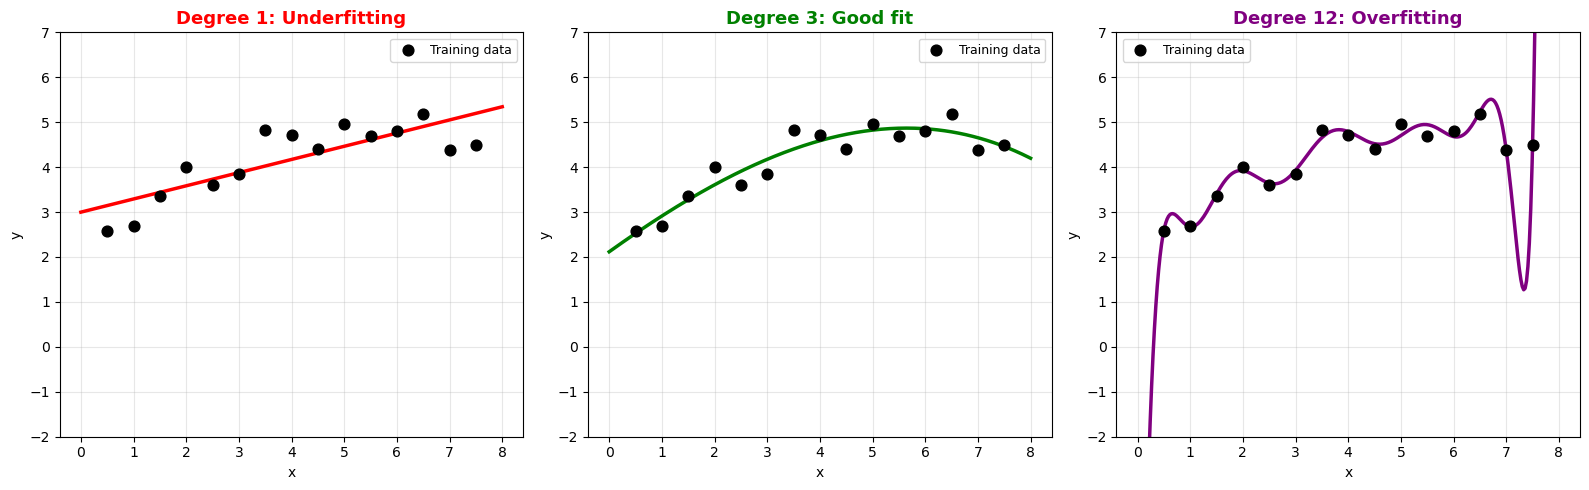

Degree 1:  Too simple - can't capture the curve (UNDERFITTING)
Degree 3:  Captures the trend without chasing noise
Degree 12: Passes through every point - memorized the training data (OVERFITTING)

15 data points, 13 parameters (degree 12) → almost as many parameters as data points!


In [138]:
# 15 points with a clear quadratic pattern + noise
np.random.seed(42)
x_small = np.linspace(0.5, 7.5, 15)
y_small = 2 + 0.8 * x_small - 0.05 * x_small**2 + np.random.normal(0, 0.4, 15)

plot_polynomial_fits(
    x_small, y_small, degrees=[1, 3, 12],
    titles=['Degree 1: Underfitting', 'Degree 3: Good fit', 'Degree 12: Overfitting'],
    colors=['red', 'green', 'purple']
)

print("Degree 1:  Too simple - can't capture the curve (UNDERFITTING)")
print("Degree 3:  Captures the trend without chasing noise")
print("Degree 12: Passes through every point - memorized the training data (OVERFITTING)")
print(f"\n15 data points, 13 parameters (degree 12) → almost as many parameters as data points!")

### Explore Overfitting Live

Slide the polynomial degree up from 1 to 14 and watch the model evolve. At what degree does it start chasing individual data points instead of learning the overall pattern?

In [139]:
from ipywidgets import IntSlider, VBox, interactive_output
from IPython.display import display, Image
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg
from sklearn.linear_model import LinearRegression
import io

degree_slider = IntSlider(min=1, max=14, step=1, value=1,
    description='Poly Degree:', style={'description_width': '120px'}, layout={'width': '500px'})

def explore_polynomial(degree):
    from sklearn.preprocessing import PolynomialFeatures as PF

    poly = PF(degree=degree, include_bias=False)
    X_poly_train = poly.fit_transform(x_small.reshape(-1, 1))
    model = LinearRegression().fit(X_poly_train, y_small)

    train_mse = mse_loss(model.predict(X_poly_train), y_small)

    fig = Figure(figsize=(14, 5))
    FigureCanvasAgg(fig)
    ax_fit, ax_info = fig.subplots(1, 2)

    # Left: Polynomial fit on the 15 points
    ax_fit.scatter(x_small, y_small, color='black', s=80, zorder=5, label='Training data (15 pts)')
    x_plot = np.linspace(-0.5, 8.5, 300)
    y_true = 2 + 0.8 * x_plot - 0.05 * x_plot**2
    ax_fit.plot(x_plot, y_true, 'gray', linewidth=1, linestyle='--', alpha=0.5, label='True pattern')
    y_pred = model.predict(poly.transform(x_plot.reshape(-1, 1)))
    y_pred_clipped = np.clip(y_pred, -2, 8)
    color = '#2ecc71' if degree <= 5 else '#e67e22' if degree <= 8 else '#e74c3c'
    ax_fit.plot(x_plot, y_pred_clipped, color=color, linewidth=2.5,
                label=f'Degree {degree} ({degree+1} params)')
    ax_fit.set_ylim(-2, 8)
    ax_fit.set_xlabel('x', fontsize=11)
    ax_fit.set_ylabel('y', fontsize=11)
    ax_fit.set_title(f'Polynomial Degree {degree}', fontsize=12, fontweight='bold', color=color)
    ax_fit.legend(fontsize=9)
    ax_fit.grid(True, alpha=0.3)

    # Right: Parameters vs data points ratio + train MSE
    ratio = (degree + 1) / 15
    bar_colors = ['#3498db', '#e74c3c' if ratio > 0.6 else '#2ecc71']
    ax_info.bar(['Train MSE', 'Params / Data'], [train_mse, ratio], color=bar_colors, width=0.5)
    ax_info.text(0, train_mse + 0.03, f'{train_mse:.4f}', ha='center', fontsize=12, fontweight='bold')
    ax_info.text(1, ratio + 0.03, f'{degree+1}/15 = {ratio:.0%}', ha='center', fontsize=12, fontweight='bold')

    if ratio > 0.8:
        verdict = 'Almost as many parameters as data points!'
        verdict_color = '#e74c3c'
    elif ratio > 0.4:
        verdict = 'Getting complex - watch for overfitting'
        verdict_color = '#e67e22'
    elif train_mse > 0.5:
        verdict = 'Too simple - underfitting'
        verdict_color = '#e67e22'
    else:
        verdict = 'Good balance of fit and simplicity'
        verdict_color = '#2ecc71'

    ax_info.set_title(verdict, fontsize=11, fontweight='bold', color=verdict_color)
    ax_info.set_ylim(0, max(1.2, train_mse * 1.3))
    ax_info.grid(True, alpha=0.3, axis='y')

    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    display(Image(data=buf.getvalue()))

out = interactive_output(explore_polynomial, {'degree': degree_slider})
display(VBox([degree_slider, out]))

### Detecting Overfitting: The Train/Test Gap

The polynomial visual made overfitting obvious - we could *see* the wiggly line chasing noise. But in real ML you're working with dozens of features and thousands of dimensions. You can't eyeball the fit.

Instead, you track **train error vs test error** as you increase model complexity. When test error starts rising while train error keeps falling, that gap IS overfitting. This is the standard diagnostic.

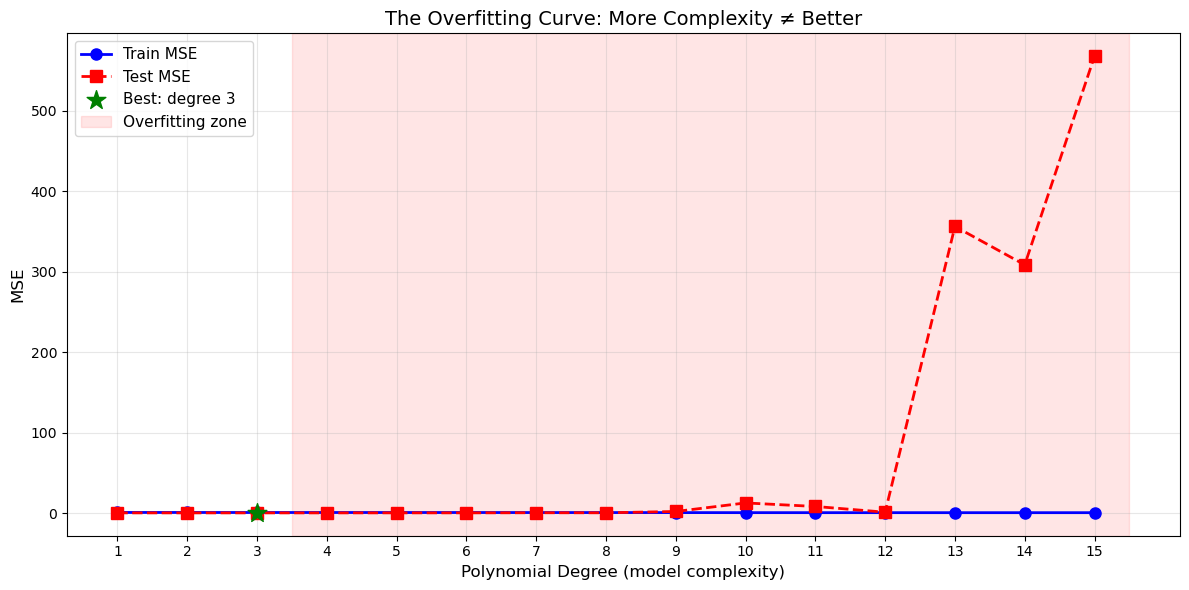

50 training points, sweeping polynomial degrees 1-15:
  Train MSE drops monotonically - more parameters always fit training data better
  Test MSE hits a minimum at degree 3, then explodes

This divergence is how you detect overfitting when you can't visualize the fit.


In [140]:
from sklearn.preprocessing import PolynomialFeatures

# Deliberately tiny sample from California Housing - forces overfitting at high degrees
np.random.seed(42)
train_idx = np.random.choice(len(X_train_norm), 50, replace=False)
test_idx = np.random.choice(len(X_test_norm), 200, replace=False)

X_small_train, y_small_train = X_train_norm[train_idx], y_train[train_idx]
X_small_test, y_small_test = X_test_norm[test_idx], y_test[test_idx]

degrees = list(range(1, 16))
train_mses, test_mses = [], []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_small_train.reshape(-1, 1))
    X_test_poly = poly.transform(X_small_test.reshape(-1, 1))
    poly_model = LinearRegression().fit(X_train_poly, y_small_train)
    train_mses.append(mse_loss(poly_model.predict(X_train_poly), y_small_train))
    test_mses.append(mse_loss(poly_model.predict(X_test_poly), y_small_test))

best_degree = plot_complexity_curve(degrees, train_mses, test_mses)

print(f"50 training points, sweeping polynomial degrees 1-15:")
print(f"  Train MSE drops monotonically - more parameters always fit training data better")
print(f"  Test MSE hits a minimum at degree {best_degree}, then explodes")
print(f"\nThis divergence is how you detect overfitting when you can't visualize the fit.")

### Extrapolation: Where Overfitting Gets Dangerous

Overfit models don't just fail on held-out test data from the same distribution - they **completely collapse** when asked to predict outside the training range. This is called **extrapolation**, and it's where overfitting goes from "slightly worse accuracy" to "dangerously wrong predictions."

An overfit polynomial might look reasonable between x=1 and x=7 (where the training data lives), but ask it to predict at x=9 and it might return a wildly wrong answer - because it learned the noise pattern, not the real trend, and noise doesn't generalize outside the data range.

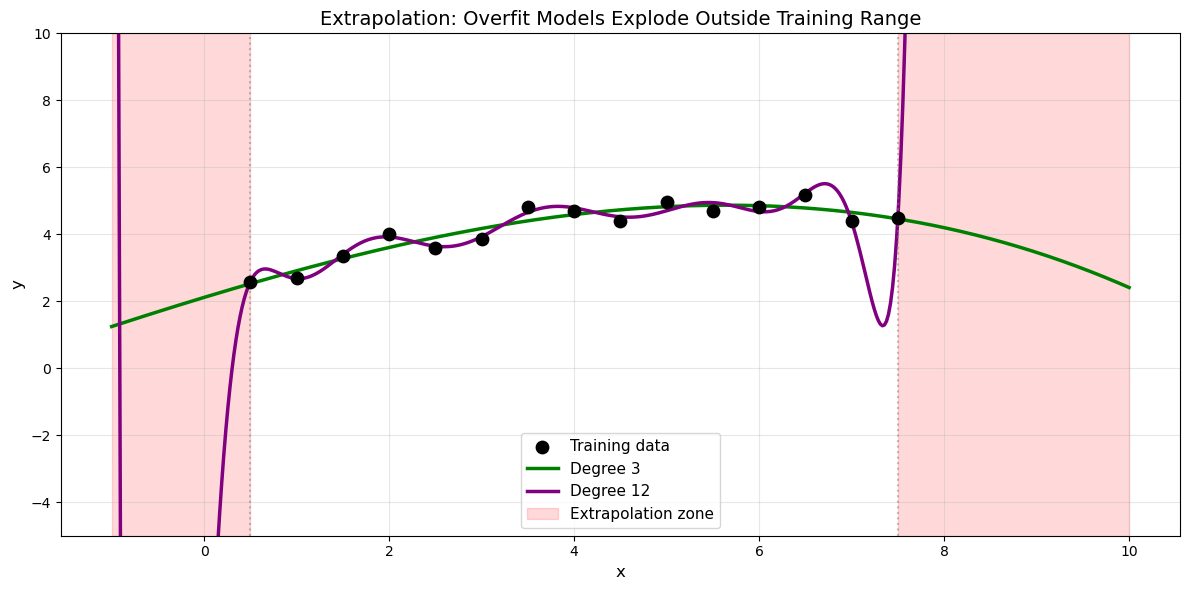

Inside the training range (white): both models look reasonable
Outside the training range (red): degree 12 shoots off wildly

This is why overfit models are dangerous in production!


In [141]:
# Degree 3 vs 12: what happens outside the training range?
plot_extrapolation(x_small, y_small)

print("Inside the training range (white): both models look reasonable")
print("Outside the training range (red): degree 12 shoots off wildly")
print("\nThis is why overfit models are dangerous in production!")

### Overfitting Summary

| Symptom | What It Means |
|---------|---------------|
| Training loss keeps dropping | Model memorizes training data |
| Test loss starts rising | Model fails to generalize |
| Wild predictions outside training range | Learned noise, not the real pattern |
| Train/test gap widens with complexity | Too many parameters for the data |

The recipe for overfitting: **too many parameters + too little data + too much noise**. This is the exact same phenomenon in neural networks - just with millions of parameters instead of 12.

### Early Stopping - Catching It During Training

We detected overfitting above by comparing different polynomial degrees after training. In practice, you want to catch it **during** training by monitoring test loss at each iteration.

Let's reuse our 15 synthetic points - split 10 for training, 5 for testing - and train a degree-8 polynomial with gradient descent. With 8 features and only 10 training points, the model will overfit as it trains:

Polynomial features - each original x value becomes 8 features:


,Original x,x^1,x^2,x^3,x^4,x^5,x^6,x^7,x^8
0,0.5,0.5,0.25,0.12,0.06,0.03,0.02,0.01,0.00
1,1.0,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00
2,1.5,1.5,2.25,3.38,5.06,7.59,11.39,17.09,25.63
3,2.0,2.0,4.00,8.00,16.00,32.00,64.00,128.00,256.00


10 training points x 8 features = 80 values. But only 10 equations.
More unknowns than equations - perfect recipe for overfitting.

Weights after 500 iterations:


,Feature,Weight
0,x^1,0.6020
1,x^2,0.2942
2,x^3,0.1053
3,x^4,-0.0010
4,x^5,-0.0578
5,x^6,-0.0845
6,x^7,-0.0919
7,x^8,-0.0867


These weights are what the model learned. With early stopping, we'd use the
weights from iteration 72 instead of iteration 500.



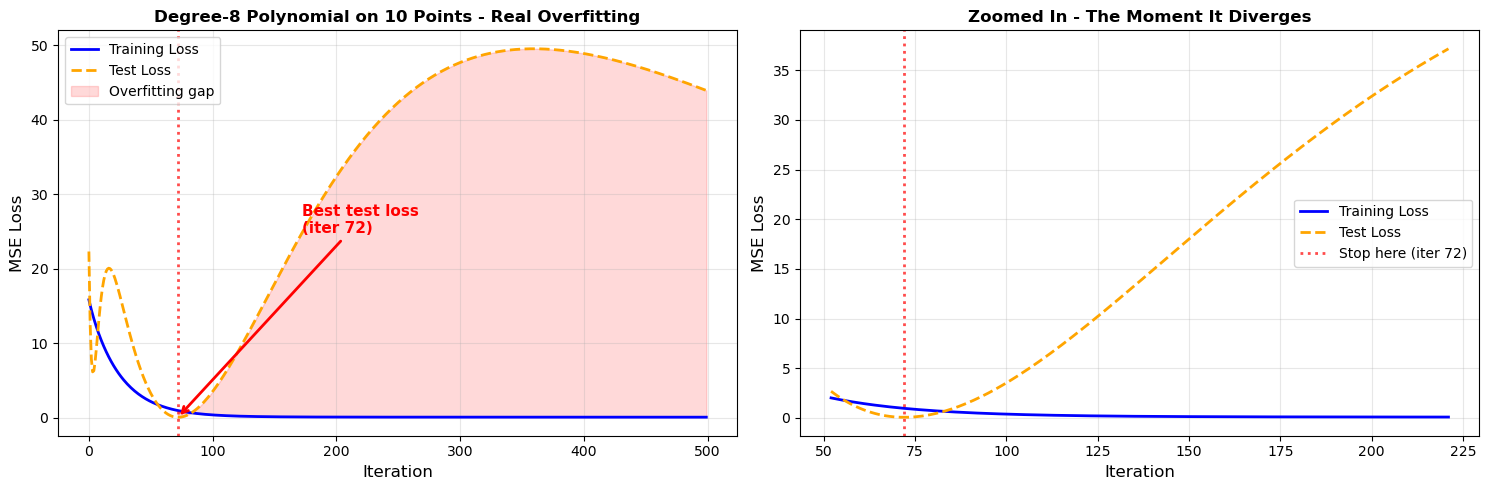

Training loss keeps dropping - the model memorizes the 10 training points.
Test loss hits minimum at iteration 72, then rises as the model overfits.

Early stopping = save the best weights (at iter 72) and stop.
We'll implement this properly with neural networks in later lessons.


In [142]:
# Split the 15 synthetic points: 10 train, 5 test
x_es_train, y_es_train = x_small[:10], y_small[:10]
x_es_test, y_es_test = x_small[10:], y_small[10:]

# Create degree-8 polynomial features (8 features from 10 points = recipe for overfitting)
poly_es = PolynomialFeatures(degree=8, include_bias=False)
X_es_train = poly_es.fit_transform(x_es_train.reshape(-1, 1))
X_es_test = poly_es.transform(x_es_test.reshape(-1, 1))

# What do polynomial features look like? Each row gets x, x^2, x^3, ... x^8
poly_names = [f'x^{i}' for i in range(1, 9)]
print("Polynomial features - each original x value becomes 8 features:")
poly_df = pd.DataFrame(X_es_train[:4].round(2), columns=poly_names)
poly_df.insert(0, 'Original x', x_es_train[:4].round(2))
display(poly_df)
print(f"10 training points x 8 features = 80 values. But only 10 equations.")
print(f"More unknowns than equations - perfect recipe for overfitting.\n")

# Standardize (polynomial features blow up without this)
poly_mean = X_es_train.mean(axis=0)
poly_std = X_es_train.std(axis=0) + 1e-8
X_es_train_s = (X_es_train - poly_mean) / poly_std
X_es_test_s = (X_es_test - poly_mean) / poly_std

# Gradient descent - track both train and test loss
weights_es = np.zeros(8)
bias_es = 0.0
lr_es = 0.01
train_losses_es, test_losses_es = [], []
best_test_loss = float('inf')
best_iter = 0

for i in range(500):
    train_preds = X_es_train_s @ weights_es + bias_es
    test_preds = X_es_test_s @ weights_es + bias_es
    
    train_loss = ((train_preds - y_es_train) ** 2).mean()
    test_loss = ((test_preds - y_es_test) ** 2).mean()
    train_losses_es.append(train_loss)
    test_losses_es.append(test_loss)
    
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_iter = i
    
    # Update using training data only
    errors = train_preds - y_es_train
    n = len(y_es_train)
    weights_es -= lr_es * (2/n) * (X_es_train_s.T @ errors)
    bias_es -= lr_es * (2/n) * errors.sum()

# Show the learned weights
print("Weights after 500 iterations:")
es_weight_df = pd.DataFrame({
    'Feature': poly_names,
    'Weight': weights_es.round(4),
})
display(es_weight_df)
print(f"These weights are what the model learned. With early stopping, we'd use the")
print(f"weights from iteration {best_iter} instead of iteration 500.\n")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(train_losses_es, 'b-', linewidth=2, label='Training Loss')
axes[0].plot(test_losses_es, 'orange', linewidth=2, linestyle='--', label='Test Loss')
axes[0].axvline(x=best_iter, color='red', linestyle=':', linewidth=2, alpha=0.7)
axes[0].annotate(f'Best test loss\n(iter {best_iter})', xy=(best_iter, best_test_loss),
                 xytext=(best_iter + 100, max(test_losses_es) * 0.5),
                 fontsize=11, fontweight='bold', color='red',
                 arrowprops=dict(arrowstyle='->', color='red', lw=2))
axes[0].fill_between(range(best_iter, 500),
                     train_losses_es[best_iter:],
                     test_losses_es[best_iter:],
                     alpha=0.15, color='red', label='Overfitting gap')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Degree-8 Polynomial on 10 Points - Real Overfitting', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: zoomed view around the divergence point
zoom_start = max(0, best_iter - 20)
zoom_end = min(500, best_iter + 150)
axes[1].plot(range(zoom_start, zoom_end), train_losses_es[zoom_start:zoom_end],
             'b-', linewidth=2, label='Training Loss')
axes[1].plot(range(zoom_start, zoom_end), test_losses_es[zoom_start:zoom_end],
             'orange', linewidth=2, linestyle='--', label='Test Loss')
axes[1].axvline(x=best_iter, color='red', linestyle=':', linewidth=2, alpha=0.7,
                label=f'Stop here (iter {best_iter})')
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('MSE Loss', fontsize=12)
axes[1].set_title('Zoomed In - The Moment It Diverges', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Training loss keeps dropping - the model memorizes the 10 training points.")
print(f"Test loss hits minimum at iteration {best_iter}, then rises as the model overfits.")
print(f"\nEarly stopping = save the best weights (at iter {best_iter}) and stop.")
print(f"We'll implement this properly with neural networks in later lessons.")

## Part 11: Multiple Features - Using All Available Information

We've been working with a single feature (income) and got R² around 0.46. That means income alone explains less than half the variation in house prices. The model is doing its best, but a straight line through one feature can only capture so much.

But we have 8 features in this dataset. Each one adds information the model could use. Location matters for housing. So does house age, number of rooms, and population density. Right now the model is ignoring all of that.

The conceptual shift is small but important: instead of one weight controlling the slope of one line, we now have one weight *per feature*. The prediction becomes a weighted sum of all features plus a bias. More weights means more "knobs" for gradient descent to turn - more ways to fit the data. Let's see the full picture:

In [143]:
# First, let's see all 8 features - this is what the model can work with
print("All 8 features available:")
display(df[list(california.feature_names) + ['MedHouseVal']].head(6))

print(f"\nWith 1 feature (income), our model was:")
print(f"  prediction = weight x income + bias   (2 parameters)")
print(f"\nWith all 8 features, it becomes:")
print(f"  prediction = w1 x income + w2 x house_age + w3 x rooms + ... + bias   (9 parameters)")
print(f"\nSame gradient descent. Same loss function. Just more weights to optimize.")

All 8 features available:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697



With 1 feature (income), our model was:
  prediction = weight x income + bias   (2 parameters)

With all 8 features, it becomes:
  prediction = w1 x income + w2 x house_age + w3 x rooms + ... + bias   (9 parameters)

Same gradient descent. Same loss function. Just more weights to optimize.


### Adding Features Progressively

Does adding more features actually help? Let's find out by training models with progressively more features and watching R² change. If a feature carries useful signal about house prices, adding it should improve predictions.

,Features,Num features,Num weights,R² (test)
0,Income only,1,2,0.4589
1,Income + Location,3,4,0.5721
2,+ Housing chars,5,6,0.5814
3,All 8 features,8,9,0.5758


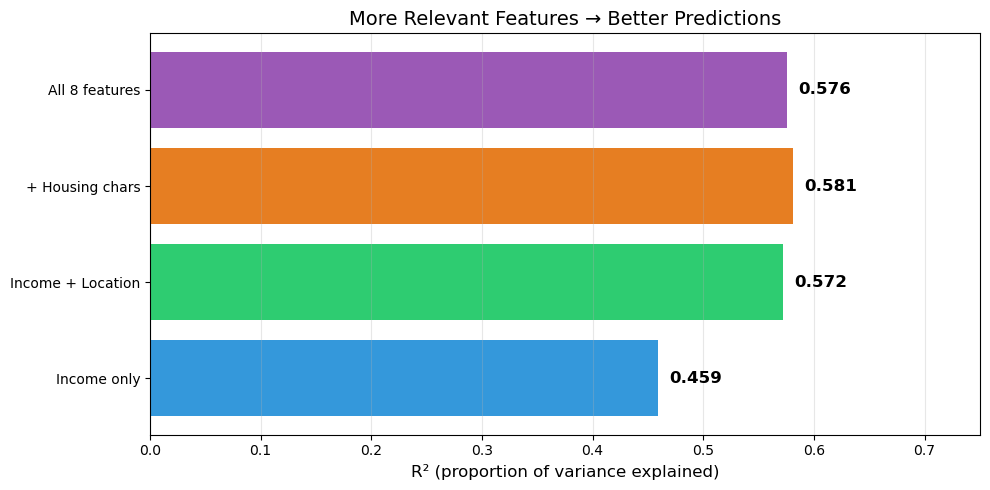

In [144]:
# Progressive feature addition: watch R² climb as we add relevant features
feature_sets = [
    (['MedInc'], 'Income only'),
    (['MedInc', 'Latitude', 'Longitude'], 'Income + Location'),
    (['MedInc', 'Latitude', 'Longitude', 'HouseAge', 'AveRooms'], '+ Housing chars'),
    (list(california.feature_names), 'All 8 features'),
]

r2_scores = []
results_rows = []

for feature_list, label in feature_sets:
    X_subset = df[feature_list].values
    X_sub_train, X_sub_test, y_sub_train, y_sub_test = train_test_split(
        X_subset, y, test_size=0.2, random_state=42
    )
    scaler = StandardScaler()
    X_sub_train_s = scaler.fit_transform(X_sub_train)
    X_sub_test_s = scaler.transform(X_sub_test)
    
    model_sub = LinearRegression().fit(X_sub_train_s, y_sub_train)
    sub_preds = model_sub.predict(X_sub_test_s)
    r2 = compute_metrics(y_sub_test, sub_preds)['R²']
    r2_scores.append((label, r2))
    
    results_rows.append({
        'Features': label,
        'Num features': len(feature_list),
        'Num weights': len(feature_list) + 1,
        'R² (test)': round(r2, 4),
    })

results_df = pd.DataFrame(results_rows)
display(results_df)

# Visualize the improvement
plot_r2_progression(
    [r[0] for r in r2_scores],
    [r[1] for r in r2_scores]
)
plt.show()

The biggest jump came from adding location (latitude and longitude). That makes sense - a house in San Francisco costs more than an identical house in the Central Valley, and income alone can't capture that.

But notice something: going from 5 features to all 8 barely moved the needle. More features doesn't automatically mean better predictions. Each feature only helps if it carries signal the other features don't already provide.

Now let's look at what the model actually learned - the weight values for each feature. Remember: each weight tells the model how much that feature should influence the prediction. A large positive weight means "when this feature goes up, the predicted price goes up." A large negative weight means the opposite.

In [145]:
# Show the actual weight values for the full 8-feature model
print("Weights learned by gradient descent (8-feature model):")
weight_df = pd.DataFrame({
    'Feature': list(california.feature_names),
    'Weight': model_sub.coef_.round(4),
})
weight_df = weight_df.reindex(weight_df['Weight'].abs().sort_values(ascending=False).index)
display(weight_df)
print(f"Bias: {model_sub.intercept_:.4f}")

print(f"\nThese are the 9 numbers (8 weights + 1 bias) that gradient descent found.")
print(f"Income has the largest positive weight - richer districts have higher prices.")
print(f"Latitude has a large negative weight - moving north (higher latitude) tends to mean lower prices.")
print(f"\nEach weight started as a random number. Gradient descent adjusted all 9 simultaneously,"  
      f"\neach step nudging them to reduce the MSE across all 16,512 training districts.")

Weights learned by gradient descent (8-feature model):


,Feature,Weight
6,Latitude,-0.8969
7,Longitude,-0.8698
0,MedInc,0.8544
3,AveBedrms,0.3393
2,AveRooms,-0.2944
1,HouseAge,0.1225
5,AveOccup,-0.0408
4,Population,-0.0023


Bias: 2.0719

These are the 9 numbers (8 weights + 1 bias) that gradient descent found.
Income has the largest positive weight - richer districts have higher prices.
Latitude has a large negative weight - moving north (higher latitude) tends to mean lower prices.

Each weight started as a random number. Gradient descent adjusted all 9 simultaneously,
each step nudging them to reduce the MSE across all 16,512 training districts.


### Feature Importance: Which Features Matter Most?

When all features are scaled to the same range (standardized), the **magnitude of each weight** tells us how important that feature is. Larger weight = stronger influence on the prediction.

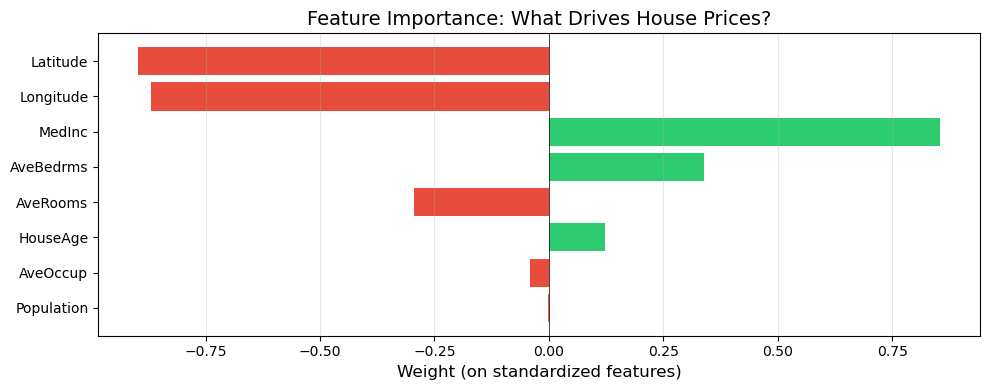

Interpreting the top features:
  MedInc  (+0.85): Higher income → higher house value
  Latitude (-0.90): Further north → lower value (LA/SF are south)
  Longitude (-0.87): Further west → higher value (coast is west)


In [146]:
# Train on all 8 features and visualize feature importance
X_all = df[california.feature_names].values
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

scaler_all = StandardScaler()
X_train_all_scaled = scaler_all.fit_transform(X_train_all)
X_test_all_scaled = scaler_all.transform(X_test_all)

full_model = LinearRegression().fit(X_train_all_scaled, y_train_all)
feature_weights = full_model.coef_

plot_feature_bars(california.feature_names, feature_weights,
                  title='Feature Importance: What Drives House Prices?')

print("Interpreting the top features:")
print(f"  MedInc  (+{feature_weights[0]:.2f}): Higher income → higher house value")
print(f"  Latitude ({feature_weights[6]:.2f}): Further north → lower value (LA/SF are south)")
print(f"  Longitude ({feature_weights[7]:.2f}): Further west → higher value (coast is west)")

### What Happens When You Add Irrelevant Features?

Not all features help. What if we add random noise columns - features with zero real relationship to house prices?

This connects back to overfitting: irrelevant features give the model more "knobs to turn" without adding real signal. With enough noise features or too little data, the model starts fitting the noise.

In [147]:
# Add 5 pure noise features (random numbers, no relationship to house prices)
np.random.seed(42)
noise_features = np.random.randn(len(X_all), 5)
X_with_noise = np.hstack([X_all, noise_features])

noise_names = ['noise_1', 'noise_2', 'noise_3', 'noise_4', 'noise_5']
all_names = list(california.feature_names) + noise_names

# Show what the data looks like with noise columns added
noise_df = pd.DataFrame(X_with_noise[:5], columns=all_names).round(3)
noise_df['Target'] = y[:5]
print("Data with 5 random noise columns added (first 5 rows):")
display(noise_df)
print("The noise columns are pure random - no relationship to house prices whatsoever.\n")

# Train/test split
X_train_noise, X_test_noise, y_train_noise, y_test_noise = train_test_split(
    X_with_noise, y, test_size=0.2, random_state=42
)

scaler_noise = StandardScaler()
X_train_noise_s = scaler_noise.fit_transform(X_train_noise)
X_test_noise_s = scaler_noise.transform(X_test_noise)

noise_model = LinearRegression().fit(X_train_noise_s, y_train_noise)
noise_preds = noise_model.predict(X_test_noise_s)
noise_r2 = compute_metrics(y_test_noise, noise_preds)['R²']

# Show the weights - real features vs noise features
weights_comparison = pd.DataFrame({
    'Feature': all_names,
    'Weight': noise_model.coef_.round(4),
    'Type': ['Real'] * 8 + ['Noise'] * 5,
})
print("Weights learned by the model:")
display(weights_comparison)

print(f"\nR² with 8 real features:     {compute_metrics(y_test_all, full_model.predict(X_test_all_scaled))['R²']:.4f}")
print(f"R² with 8 real + 5 noise:    {noise_r2:.4f}")
print(f"\nThe noise features got small weights (close to 0) - the model mostly ignored them.")
print(f"With enough noise features and too little data, this wouldn't be the case - overfitting.")

Data with 5 random noise columns added (first 5 rows):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,noise_1,noise_2,noise_3,noise_4,noise_5,Target
0,8.325,41.0,6.984,1.024,322.0,2.556,37.88,-122.23,0.497,-0.138,0.648,1.523,-0.234,4.526
1,8.301,21.0,6.238,0.972,2401.0,2.110,37.86,-122.22,-0.234,1.579,0.767,-0.469,0.543,3.585
2,7.257,52.0,8.288,1.073,496.0,2.802,37.85,-122.24,-0.463,-0.466,0.242,-1.913,-1.725,3.521
3,5.643,52.0,5.817,1.073,558.0,2.548,37.85,-122.25,-0.562,-1.013,0.314,-0.908,-1.412,3.413
4,3.846,52.0,6.282,1.081,565.0,2.181,37.85,-122.25,1.466,-0.226,0.068,-1.425,-0.544,3.422


The noise columns are pure random - no relationship to house prices whatsoever.

Weights learned by the model:


,Feature,Weight,Type
0,MedInc,0.8543,Real
1,HouseAge,0.1224,Real
2,AveRooms,-0.2944,Real
3,AveBedrms,0.3392,Real
4,Population,-0.0023,Real
5,AveOccup,-0.0409,Real
6,Latitude,-0.8972,Real
7,Longitude,-0.8700,Real
8,noise_1,-0.0064,Noise
9,noise_2,-0.0018,Noise



R² with 8 real features:     0.5758
R² with 8 real + 5 noise:    0.5757

The noise features got small weights (close to 0) - the model mostly ignored them.
With enough noise features and too little data, this wouldn't be the case - overfitting.


### Multiple Features Summary

| Features Used | R² (Test) | Insight |
|--------------|-----------|---------|
| Income only | ~0.46 | One feature explains 46% of variance |
| + Location | ~0.57 | Geography matters a lot for housing |
| + Housing characteristics | ~0.58 | Small additional gain |
| All 8 features | ~0.58 | Extra features don't always help! |
| All 8 + 5 noise features | ~0.58 | Noise features mostly ignored |

Key takeaways:
- More **relevant** features improve predictions (income + location = big jump)
- Adding irrelevant or redundant features can slightly **hurt** - not all features are helpful
- The matrix form `y = X @ w + b` scales to any number of features
- Feature importance (weight magnitude on scaled data) reveals what matters

## Part 12: The Limits of Linear Regression

We've spent this entire notebook on linear models. Time for an honest question: **how far can a straight line actually take you?**

Let's find out with a different dataset: fuel efficiency of cars from the 1970s and 80s. This was the era of V8 muscle cars colliding with the oil crisis - manufacturers suddenly had to care about miles per gallon. Given a car's specs, can we predict its fuel efficiency?

Auto MPG: 392 cars from the 1970s-80s

Gas guzzlers:
 car_name  cylinders  weight  horsepower  mpg
 hi 1200d          8  4732.0       193.0  9.0
ford f250          8  4615.0       215.0 10.0
chevy c20          8  4376.0       200.0 10.0

Fuel sippers:
            car_name  cylinders  weight  horsepower  mpg
           mazda glc          4  2110.0        65.0 46.6
 honda civic 1500 gl          4  1850.0        67.0 44.6
vw rabbit c (diesel)          4  2085.0        48.0 44.3


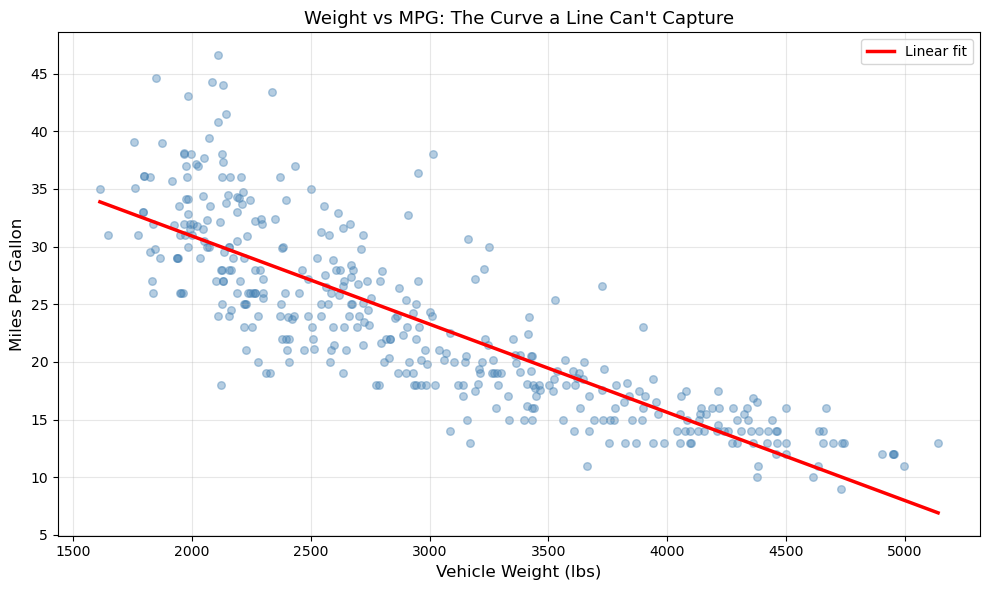


Linear regression R² = 0.79 (using all 6 features)
Decent - but look at the scatter. The real relationship curves.
No matter how many features we add, a weighted sum can't bend.


In [148]:
# Load the Auto MPG dataset
col_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
             'acceleration', 'model_year', 'origin', 'car_name']
mpg_df = pd.read_csv(DATA_PATH / "auto_mpg" / "auto-mpg.data",
                      sep=r'\s+', names=col_names, na_values='?').dropna()

# The extremes: gas guzzlers vs sippers
guzzlers = mpg_df.nsmallest(3, 'mpg')[['car_name', 'cylinders', 'weight', 'horsepower', 'mpg']]
sippers = mpg_df.nlargest(3, 'mpg')[['car_name', 'cylinders', 'weight', 'horsepower', 'mpg']]

print(f"Auto MPG: {len(mpg_df)} cars from the 1970s-80s\n")
print("Gas guzzlers:")
print(guzzlers.to_string(index=False))
print("\nFuel sippers:")
print(sippers.to_string(index=False))

# Fit linear regression on 6 numeric features
feature_cols = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
X_mpg = mpg_df[feature_cols].values
y_mpg = mpg_df['mpg'].values

X_mpg_train, X_mpg_test, y_mpg_train, y_mpg_test = train_test_split(
    X_mpg, y_mpg, test_size=0.2, random_state=42)
scaler_mpg = StandardScaler()
mpg_linear = LinearRegression().fit(scaler_mpg.fit_transform(X_mpg_train), y_mpg_train)
mpg_preds = mpg_linear.predict(scaler_mpg.transform(X_mpg_test))
mpg_r2 = compute_metrics(y_mpg_test, mpg_preds)['R²']

# The curve a line can't capture
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(mpg_df['weight'], mpg_df['mpg'], alpha=0.4, s=30, color='steelblue')
weight_only_model = LinearRegression().fit(mpg_df[['weight']].values, mpg_df['mpg'].values)
x_line = np.linspace(mpg_df['weight'].min(), mpg_df['weight'].max(), 100)
ax.plot(x_line, weight_only_model.predict(x_line.reshape(-1, 1)), 'r-', linewidth=2.5, label='Linear fit')
ax.set_xlabel('Vehicle Weight (lbs)', fontsize=12)
ax.set_ylabel('Miles Per Gallon', fontsize=12)
ax.set_title("Weight vs MPG: The Curve a Line Can't Capture", fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nLinear regression R² = {mpg_r2:.2f} (using all 6 features)")
print("Decent - but look at the scatter. The real relationship curves.")
print("No matter how many features we add, a weighted sum can't bend.")

### Can We Do Better?

We've hit a ceiling. Linear regression with all 8 features gave us R² around 0.58. That's decent, but it means 42% of the variance in house prices remains unexplained. The problem isn't the data - it's the model. A linear model can only combine features with weighted sums. It can never learn that the relationship between income and price is curved, or that location matters *differently* depending on income level. It's fundamentally limited to straight lines in high dimensions.

In Part 8 we introduced PyTorch. Let's use it to build something more powerful: a **neural network** with one hidden layer. Same training loop, same loss function (MSE), same optimizer (gradient descent). The only new ingredient is a non-linear activation function (ReLU) between layers - that's what lets the model learn curves instead of only straight lines. We'll explore how this actually works in detail in L4. For now, just watch what happens to the accuracy:

Neural network architecture: 6 inputs -> 16 hidden -> 1 output
Total parameters: 129
  Layer 1: 6 x 16 weights + 16 biases = 112
  Layer 2: 16 x 1 weights + 1 bias    = 17

All 129 start as random numbers. Gradient descent optimizes ALL of them.
First few random weights from layer 1: [-0.22905026376247406, 0.2849271297454834, 0.36953774094581604, 0.033156868070364]

After training, those same weights: [-0.024759331718087196, 0.10883273929357529, 0.7133647799491882, 0.11621612310409546]
Gradient descent adjusted all 129 parameters to minimize MSE.


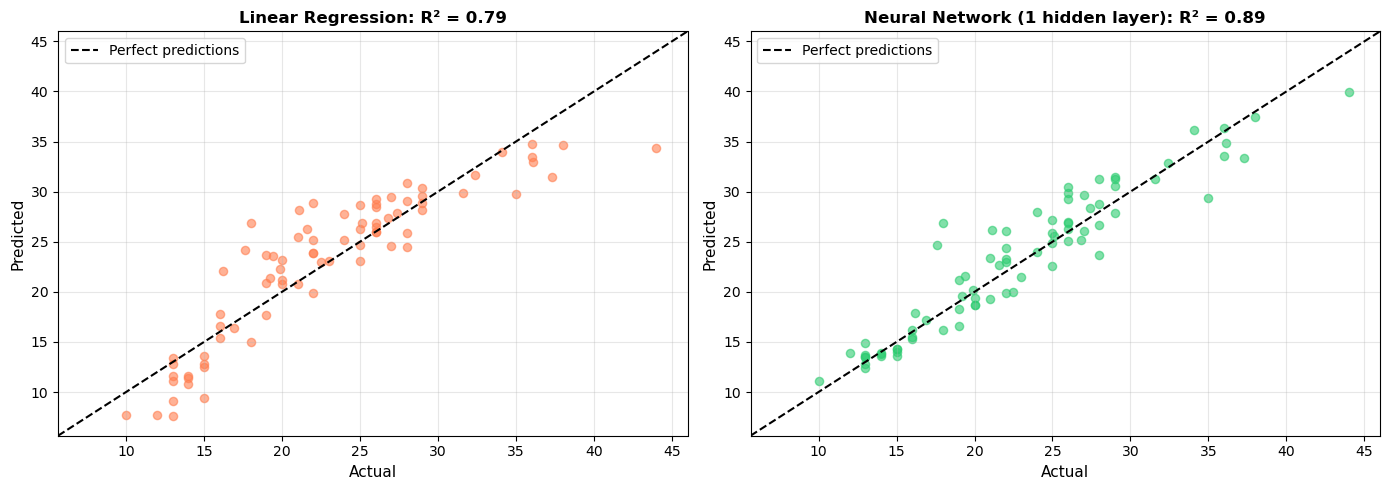


Linear regression:  R² = 0.79 (2 parameters)
Neural network:     R² = 0.89 (129 parameters)

Same data. Same loss function (MSE). Same gradient descent.
The only difference: one hidden layer with a non-linear activation (ReLU).


In [149]:
# Same data, same gradient descent - but a NON-LINEAR model
X_train_tensor = torch.FloatTensor(scaler_mpg.transform(X_mpg_train))
X_test_tensor = torch.FloatTensor(scaler_mpg.transform(X_mpg_test))
y_train_tensor = torch.FloatTensor(y_mpg_train).reshape(-1, 1)

# 2-layer neural network: Linear -> ReLU -> Linear
mpg_nn = nn.Sequential(
    nn.Linear(6, 16),   # 6 features -> 16 hidden neurons
    nn.ReLU(),           # Non-linear activation (this is the key!)
    nn.Linear(16, 1)     # 16 hidden -> 1 output (MPG prediction)
)

# How many weights does this have? Way more than our 2-parameter linear model
total_params = sum(p.numel() for p in mpg_nn.parameters())
print(f"Neural network architecture: 6 inputs -> 16 hidden -> 1 output")
print(f"Total parameters: {total_params}")
print(f"  Layer 1: 6 x 16 weights + 16 biases = {6*16 + 16}")
print(f"  Layer 2: 16 x 1 weights + 1 bias    = {16*1 + 1}")
print(f"\nAll {total_params} start as random numbers. Gradient descent optimizes ALL of them.")
print(f"First few random weights from layer 1: {mpg_nn[0].weight.data[0, :4].tolist()}")

optimizer = torch.optim.SGD(mpg_nn.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# Same training loop from Part 7
for epoch in range(1000):
    preds = mpg_nn(X_train_tensor)
    loss = loss_fn(preds, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f"\nAfter training, those same weights: {mpg_nn[0].weight.data[0, :4].tolist()}")
print(f"Gradient descent adjusted all {total_params} parameters to minimize MSE.")

# Evaluate
with torch.no_grad():
    nn_preds = mpg_nn(X_test_tensor).numpy().flatten()
nn_r2 = compute_metrics(y_mpg_test, nn_preds)['R²']

# Side-by-side: Linear vs Neural Network
plot_actual_vs_predicted(
    y_mpg_test,
    [mpg_preds, nn_preds],
    ['Linear Regression', 'Neural Network (1 hidden layer)'],
    [mpg_r2, nn_r2],
    ['coral', '#2ecc71']
)

print(f"\nLinear regression:  R² = {mpg_r2:.2f} (2 parameters)")
print(f"Neural network:     R² = {nn_r2:.2f} ({total_params} parameters)")
print(f"\nSame data. Same loss function (MSE). Same gradient descent.")
print(f"The only difference: one hidden layer with a non-linear activation (ReLU).")

That's the punchline of this notebook. Everything we learned - loss functions, gradients, gradient descent, learning rates, overfitting - applies directly to neural networks. The training loop is identical. The only thing that changed is the model: instead of `prediction = weight * x + bias` (a straight line), we have `prediction = Linear(ReLU(Linear(x)))` - two linear transformations with a non-linear activation in between.

That non-linear activation (ReLU) is what breaks the linearity constraint. Without it, stacking linear layers would just produce another linear layer. With it, the model can approximate curves, interactions, and complex patterns. How exactly this works - what ReLU does, what hidden layers represent, why depth matters - is the focus of the next lesson.

The key takeaway: **the fundamentals don't change**. You'll use the same gradient descent loop, the same concept of loss, the same train/test evaluation throughout this entire course. The models get more complex, but the training process stays the same.

## Key Takeaways

1. **Regression** predicts a continuous number (house price, fuel efficiency). The other pillar of supervised learning alongside classification.
2. **Loss function** (MSE) measures how wrong the model is. Training = minimizing loss. Lower is better.
3. **Gradient descent** minimizes loss: compute the **gradient** (slope of the loss), take a step opposite to it. Repeat.
4. **Learning rate** controls step size - too small is slow, too large overshoots and diverges.
5. **Feature scaling** (standardization) is critical. Without it, gradient descent takes lopsided steps and may fail to converge.
6. **Train/test split** is non-negotiable. Always evaluate on data the model never saw during training.
7. **Overfitting** = model memorizes training noise instead of learning the real pattern. Detect it by watching the gap between train loss and test loss.
8. **Linear models have a ceiling** - they combine features with a weighted sum, so they can never learn curved relationships. Neural networks can.

## What's Next?

We've mastered the mechanics: loss functions, gradients, gradient descent, overfitting. These concepts don't change - they're the foundation of all deep learning.

What changes is the **model**. In the next lesson, we'll build our first neural network: layers of linear transformations separated by non-linear activation functions. Same gradient descent training loop, but now the model can learn curves, interactions, and patterns that linear regression never could.

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 40px; padding-top: 10px; border-top: 1px solid #ddd;">
© 2025 Utvecklarakademin UA Aktiebolag. All rights reserved.<br>
This material is proprietary and may not be reproduced, distributed, or shared without written permission.
</div>